- Links uteis:

1 - https://theairlab.org/alfa-dataset/ (contém informações sobre o status do vôo.)

# Explorando os dados


In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


In [ ]:

def plot_generic_df(df, titulo_grafico="Análise de Dados"):
    # 1. Tratamento do Tempo (Eixo X)
    if '%time' in df.columns:
        t_zero = df['%time'].iloc[0]
        tempo_segundos = (df['%time'] - t_zero) / 1e9
    else:
        print("Coluna %time não encontrada. Usando índice como tempo.")
        tempo_segundos = df.index

    # 2. Filtrar apenas colunas numéricas (e excluir metadados de tempo/sequência)
    cols_numericas = df.select_dtypes(include=['number']).columns.tolist()
    # Ignoramos colunas que são apenas contadores ou carimbos de tempo para o plot ficar limpo
    blacklist = ['%time', 'field.header.stamp', 'field.header.seq']
    cols_para_plotar = [c for c in cols_numericas if c not in blacklist]

    # 3. Configurar Subplots dinamicamente
    # Vamos agrupar as colunas para não criar 20 subplots (ex: máximo de 3 colunas por gráfico)
    num_cols = len(cols_para_plotar)
    if num_cols == 0:
        print("Nenhuma coluna numérica encontrada para plotar.")
        return

    # Criamos subplots: um para cada 3 variáveis (ou conforme sua preferência)
    v_limit = 4 # variáveis por subplot
    n_subplots = (num_cols + v_limit - 1) // v_limit
    
    fig, axes = plt.subplots(n_subplots, 1, figsize=(12, 4 * n_subplots), sharex=True)
    
    # Se houver apenas 1 subplot, o matplotlib não retorna uma lista, então ajustamos:
    if n_subplots == 1: axes = [axes]

    # 4. Plotagem em massa
    for i in range(n_subplots):
        start = i * v_limit
        end = start + v_limit
        batch_cols = cols_para_plotar[start:end]
        
        for col in batch_cols:
            # Pegamos apenas o final do nome da coluna (ex: 'linear.x') para a legenda
            label_curto = col.split('.')[-1]
            axes[i].plot(tempo_segundos, df[col], label=label_curto)
        
        axes[i].legend(loc='upper right', fontsize='small')
        axes[i].grid(True, alpha=0.3)
        axes[i].set_ylabel("Valores")

    axes[-1].set_xlabel("Tempo (segundos)")
    plt.suptitle(titulo_grafico, fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

# Exemplo de uso para o seu primeiro DF:
# plot_generic_df(df_primeiro, titulo_grafico=primeira_chave)

# Abrindo todos os arquivos e salvando em um dicionário de dfs



In [ ]:
pasta = Path('../data/01_raw/processed/carbonZ_2018-07-18-15-53-31_1_engine_failure')

caminho_datasets = list(pasta.glob('*.csv'))

#for f in caminho_datasets:
#    print(f)


In [4]:
dfs = {f.stem: pd.read_csv(f) for f in pasta.glob('*.csv')}


In [5]:
len(dfs.keys())


34

São 34 dataframes para se explorar. 

# Dataframe 1 

In [7]:
list(dfs.keys())[0]

'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-gps_vel'

In [32]:
i = 0

primeira_chave = list(dfs.keys())[i]
df1 = dfs[primeira_chave]


In [33]:
df1

,%time,field.header.seq,field.header.stamp,field.header.frame_id,field.twist.linear.x,field.twist.linear.y,field.twist.linear.z,field.twist.angular.x,field.twist.angular.y,field.twist.angular.z
0,1531943810933587063,1286,1531943810933254299,map,19.086618,-1.989246,0.0,0.0,0.0,0.0
1,1531943811143678844,1287,1531943811143058500,map,19.315361,-0.752150,0.0,0.0,0.0,0.0
2,1531943811338236330,1288,1531943811337205271,map,19.146784,-0.350922,0.0,0.0,0.0,0.0
3,1531943811549229158,1289,1531943811548014901,map,18.873702,-0.487633,0.0,0.0,0.0,0.0
4,1531943811742729793,1290,1531943811741930763,map,18.355274,-0.416539,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
657,1531943942336272938,1943,1531943942335946573,map,-11.029684,-1.563865,0.0,0.0,0.0,0.0
658,1531943942544529002,1944,1531943942544183982,map,-11.015610,-1.192788,0.0,0.0,0.0,0.0
659,1531943942747957693,1945,1531943942747002215,map,-10.878427,-0.829410,0.0,0.0,0.0,0.0
660,1531943942945854826,1946,1531943942945630604,map,-10.699969,-0.463429,0.0,0.0,0.0,0.0


In [34]:
df1.columns

Index(['%time', 'field.header.seq', 'field.header.stamp',
       'field.header.frame_id', 'field.twist.linear.x', 'field.twist.linear.y',
       'field.twist.linear.z', 'field.twist.angular.x',
       'field.twist.angular.y', 'field.twist.angular.z'],
      dtype='str')

## Interpretando as Colunas

- %time e field.header.stamp: São os marcadores de tempo. O %time geralmente é o tempo de recepção do sistema, enquanto o stamp é quando o sensor gerou o dado. 

- field.twist.linear.x, y, z: Representam a velocidade linear (em m/s).

- linear.z: Esta é a sua coluna de ouro para falha de motor. Em um voo nivelado, ela deve estar próxima de 0. Se o motor falha, você verá um valor negativo persistente (descida), independentemente do que o piloto ordene.

- linear.x e linear.y: Velocidade de deslocamento horizontal (Norte/Sul, Leste/Oeste).

- field.twist.angular.x, y, z: Representam a velocidade de rotação (taxas de giro em rad/s) em torno dos eixos da aeronave.

No ALFA, se o motor falha em um avião de asa fixa (como o CarbonZ), ele perde sustentação e pode começar a girar (stall). Um aumento repentino em angular.x (roll) ou angular.y (pitch) sem comando prévio indica instabilidade causada pela falha.

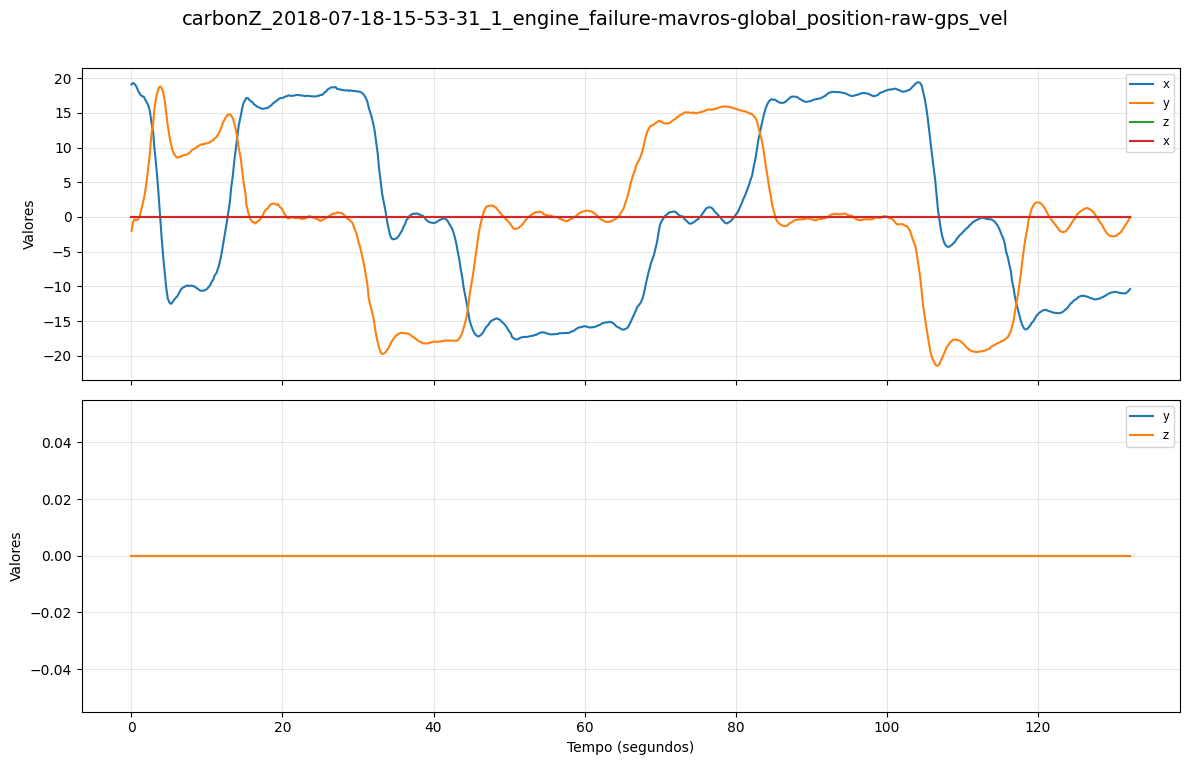

In [35]:
plot_generic_df(df1, titulo_grafico=primeira_chave)

O que está acontecendo provavelmente é um destes dois cenários:

1. O "Voo Fantasma" (Tópico Inativo)

No sistema ROS, quando um sensor não está enviando dados ou o drone ainda está no chão/estático, o log registra apenas zeros ou valores constantes de inicialização. Se as velocidades X e Y oscilam minimamente em torno de zero e Z está parado, esse log pode ser apenas o período de "pre-arm" (o drone parado na pista esperando o comando de decolagem).

2. Velocidade vs. Posição Global

O arquivo que você abriu é o global_position-raw-gps_vel. O GPS às vezes demora para "travar" o sinal (lock) ou só começa a reportar variações significativas após o movimento real começar.

# Dataframe 2

In [19]:
i = 1
list(dfs.keys())[i]

'carbonZ_2018-07-18-15-53-31_1_engine_failure-failure_status-engines'

In [27]:
primeira_chave = list(dfs.keys())[i]
df2 = dfs[primeira_chave]


In [30]:
df2

,%time,engine_status
0,1531943927129305993,1
1,1531943927330826960,1
2,1531943927532631123,1
3,1531943927734763284,1
4,1531943927931240336,1
...,...,...
76,1531943942329959052,1
77,1531943942529070508,1
78,1531943942732934330,1
79,1531943942938755028,1


In [28]:
# 2. Renomeando a coluna para algo sugestivo
df2 = df2.rename(columns={'field.data': 'engine_status'})

In [29]:
df2.columns

Index(['%time', 'engine_status'], dtype='str')

In [ ]:
df2['engine_status'].unique()

array([1])

## Interpretando as Colunas

- %time e field.header.stamp: São os marcadores de tempo. O %time geralmente é o tempo de recepção do sistema, enquanto o stamp é quando o sensor gerou o dado. 

- engine_status: Indica se a aeronave está saudável ou com falha. De acordo com o Link [1](https://theairlab.org/alfa-dataset/), os dados deste vôo possuíram 16 segundos de voo após a falha, logo, pelo gráfico abaixo o valor 1 indica falha.

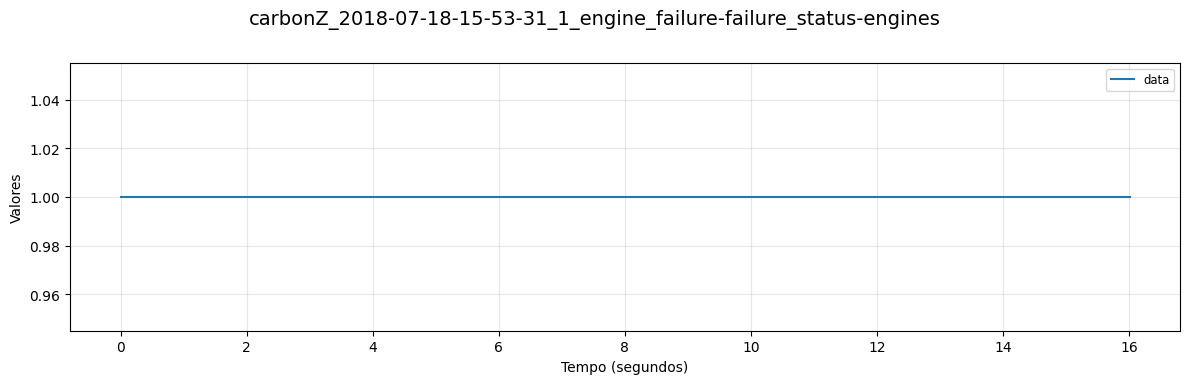

In [ ]:
plot_generic_df(df2, titulo_grafico=primeira_chave)

In [ ]:
# O merge_asof alinha o status ao tempo do GPS sem criar linhas extras com NaN
df_merge1 = pd.merge_asof(df1, df2, on='%time', direction='backward')

print(df_alinhado['engine_status'].value_counts())

engine_status
1.0    81
Name: count, dtype: int64


In [39]:
df_alinhado

,%time,field.header.seq,field.header.stamp,field.header.frame_id,field.twist.linear.x,field.twist.linear.y,field.twist.linear.z,field.twist.angular.x,field.twist.angular.y,field.twist.angular.z,engine_status
0,1531943810933587063,1286,1531943810933254299,map,19.086618,-1.989246,0.0,0.0,0.0,0.0,NaN
1,1531943811143678844,1287,1531943811143058500,map,19.315361,-0.752150,0.0,0.0,0.0,0.0,NaN
2,1531943811338236330,1288,1531943811337205271,map,19.146784,-0.350922,0.0,0.0,0.0,0.0,NaN
3,1531943811549229158,1289,1531943811548014901,map,18.873702,-0.487633,0.0,0.0,0.0,0.0,NaN
4,1531943811742729793,1290,1531943811741930763,map,18.355274,-0.416539,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
657,1531943942336272938,1943,1531943942335946573,map,-11.029684,-1.563865,0.0,0.0,0.0,0.0,1.0
658,1531943942544529002,1944,1531943942544183982,map,-11.015610,-1.192788,0.0,0.0,0.0,0.0,1.0
659,1531943942747957693,1945,1531943942747002215,map,-10.878427,-0.829410,0.0,0.0,0.0,0.0,1.0
660,1531943942945854826,1946,1531943942945630604,map,-10.699969,-0.463429,0.0,0.0,0.0,0.0,1.0


In [36]:
# Fazendo o merge ordenado pelo tempo
df_merged = pd.merge_ordered(df1, df2, on='%time', how='outer')

# Verificando os NaNs
print(f"Total de linhas após união: {len(df_merged)}")
print(f"Valores nulos em engine_status: {df_merged['engine_status'].isna().sum()}")

Total de linhas após união: 743
Valores nulos em engine_status: 662


In [37]:
df_merged

,%time,field.header.seq,field.header.stamp,field.header.frame_id,field.twist.linear.x,field.twist.linear.y,field.twist.linear.z,field.twist.angular.x,field.twist.angular.y,field.twist.angular.z,engine_status
0,1531943810933587063,1286.0,1.531944e+18,map,19.086618,-1.989246,0.0,0.0,0.0,0.0,NaN
1,1531943811143678844,1287.0,1.531944e+18,map,19.315361,-0.752150,0.0,0.0,0.0,0.0,NaN
2,1531943811338236330,1288.0,1.531944e+18,map,19.146784,-0.350922,0.0,0.0,0.0,0.0,NaN
3,1531943811549229158,1289.0,1.531944e+18,map,18.873702,-0.487633,0.0,0.0,0.0,0.0,NaN
4,1531943811742729793,1290.0,1.531944e+18,map,18.355274,-0.416539,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
738,1531943942747957693,1945.0,1.531944e+18,map,-10.878427,-0.829410,0.0,0.0,0.0,0.0,NaN
739,1531943942938755028,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
740,1531943942945854826,1946.0,1.531944e+18,map,-10.699969,-0.463429,0.0,0.0,0.0,0.0,NaN
741,1531943943134074845,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


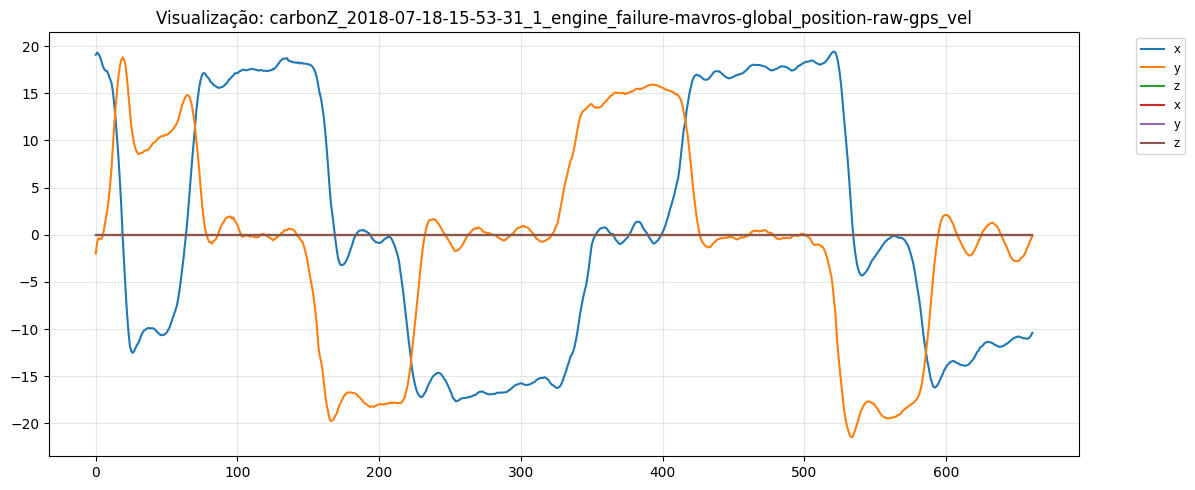

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-gps_vel ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.twist.linear.x (Numérica)
6. field.twist.linear.y (Numérica)
7. field.twist.linear.z (Numérica)
8. field.twist.angular.x (Numérica)
9. field.twist.angular.y (Numérica)
10. field.twist.angular.z (Numérica)




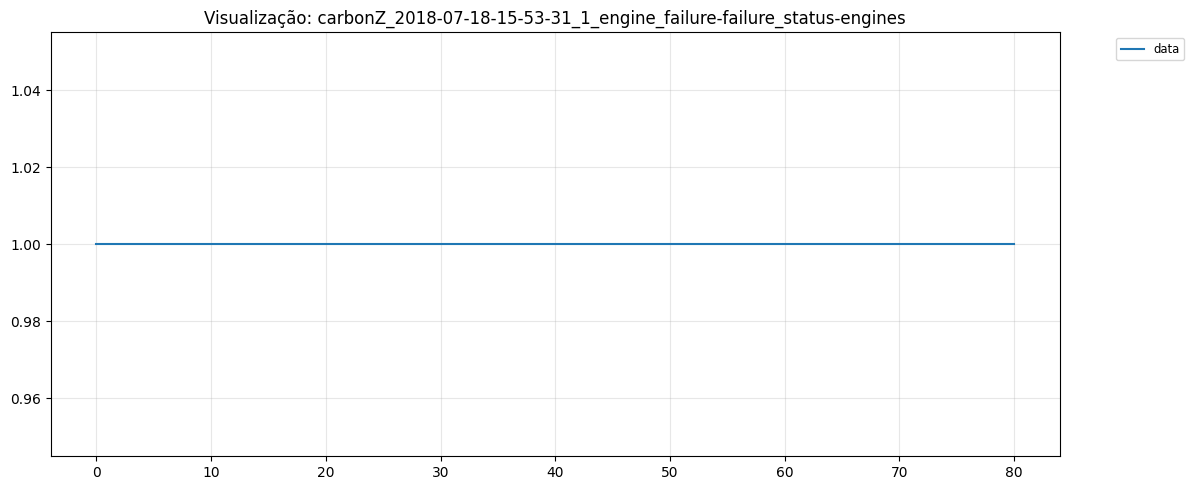

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-failure_status-engines ---
1. %time (Numérica)
2. field.data (Numérica)




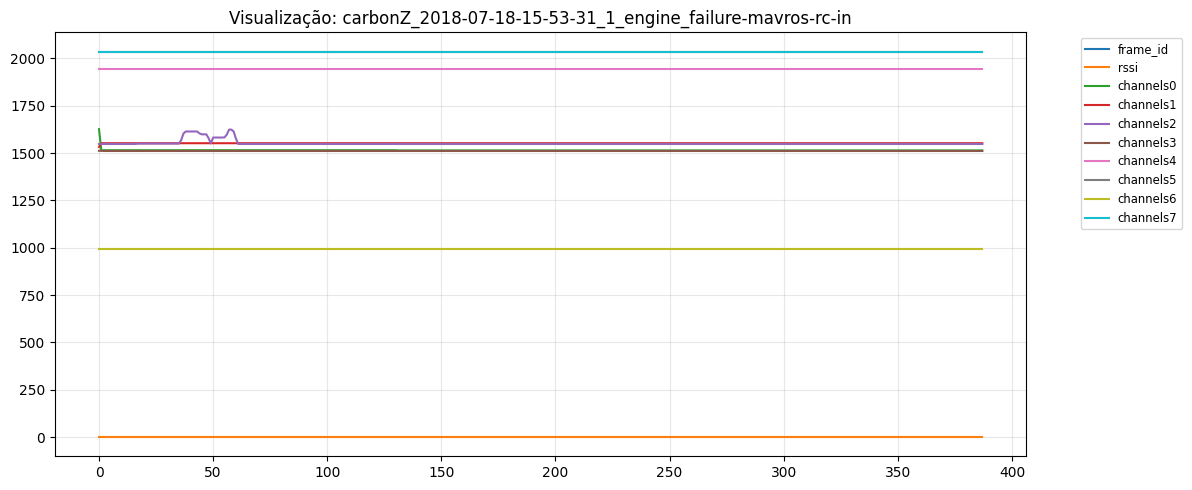

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-rc-in ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Numérica)
5. field.rssi (Numérica)
6. field.channels0 (Numérica)
7. field.channels1 (Numérica)
8. field.channels2 (Numérica)
9. field.channels3 (Numérica)
10. field.channels4 (Numérica)
11. field.channels5 (Numérica)
12. field.channels6 (Numérica)
13. field.channels7 (Numérica)
14. field.channels8 (Numérica)
15. field.channels9 (Numérica)
16. field.channels10 (Numérica)
17. field.channels11 (Numérica)
18. field.channels12 (Numérica)
19. field.channels13 (Numérica)
20. field.channels14 (Numérica)
21. field.channels15 (Numérica)




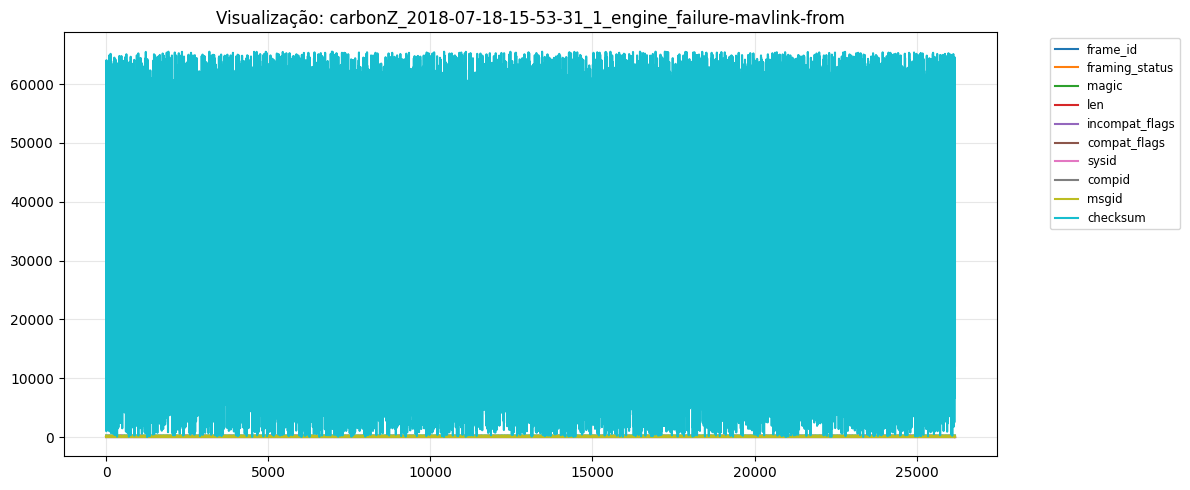

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Numérica)
5. field.framing_status (Numérica)
6. field.magic (Numérica)
7. field.len (Numérica)
8. field.incompat_flags (Numérica)
9. field.compat_flags (Numérica)
10. field.seq (Numérica)
11. field.sysid (Numérica)
12. field.compid (Numérica)
13. field.msgid (Numérica)
14. field.checksum (Numérica)
15. field.payload640 (Numérica)
16. field.payload641 (Não-Numérica)
17. field.payload642 (Não-Numérica)
18. field.payload643 (Não-Numérica)
19. field.payload644 (Não-Numérica)
20. field.payload645 (Numérica)
21. field.payload646 (Numérica)




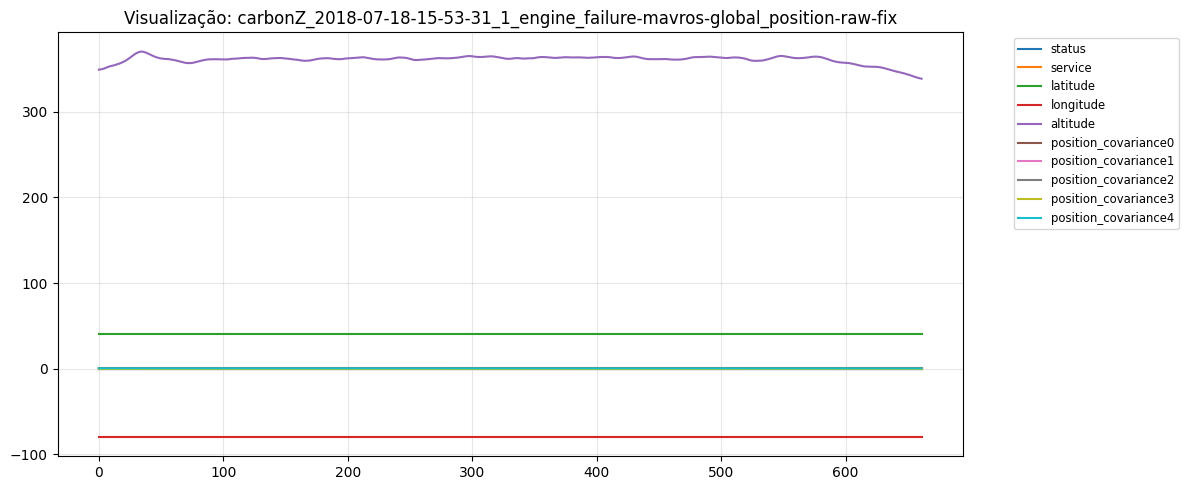

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-fix ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.status.status (Numérica)
6. field.status.service (Numérica)
7. field.latitude (Numérica)
8. field.longitude (Numérica)
9. field.altitude (Numérica)
10. field.position_covariance0 (Numérica)
11. field.position_covariance1 (Numérica)
12. field.position_covariance2 (Numérica)
13. field.position_covariance3 (Numérica)
14. field.position_covariance4 (Numérica)
15. field.position_covariance5 (Numérica)
16. field.position_covariance6 (Numérica)
17. field.position_covariance7 (Numérica)
18. field.position_covariance8 (Numérica)
19. field.position_covariance_type (Numérica)




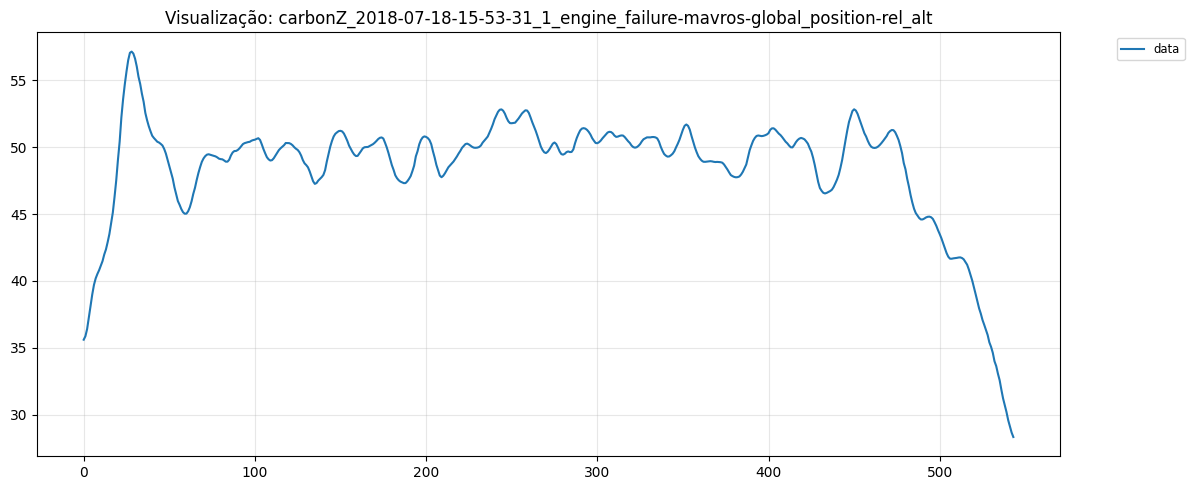

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-rel_alt ---
1. %time (Numérica)
2. field.data (Numérica)




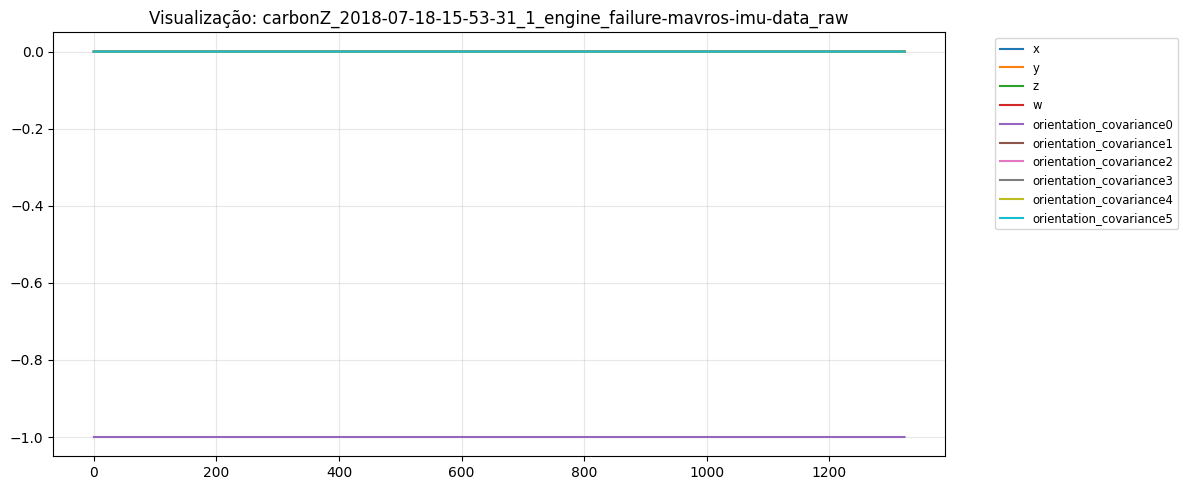

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-data_raw ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.orientation.x (Numérica)
6. field.orientation.y (Numérica)
7. field.orientation.z (Numérica)
8. field.orientation.w (Numérica)
9. field.orientation_covariance0 (Numérica)
10. field.orientation_covariance1 (Numérica)
11. field.orientation_covariance2 (Numérica)
12. field.orientation_covariance3 (Numérica)
13. field.orientation_covariance4 (Numérica)
14. field.orientation_covariance5 (Numérica)
15. field.orientation_covariance6 (Numérica)
16. field.orientation_covariance7 (Numérica)
17. field.orientation_covariance8 (Numérica)
18. field.angular_velocity.x (Numérica)
19. field.angular_velocity.y (Numérica)
20. field.angular_velocity.z (Numérica)
21. field.angular_velocity_covariance0 (Numérica)
22. field.angular_velocity_covariance1 (Numérica)
23. field.angular_veloc

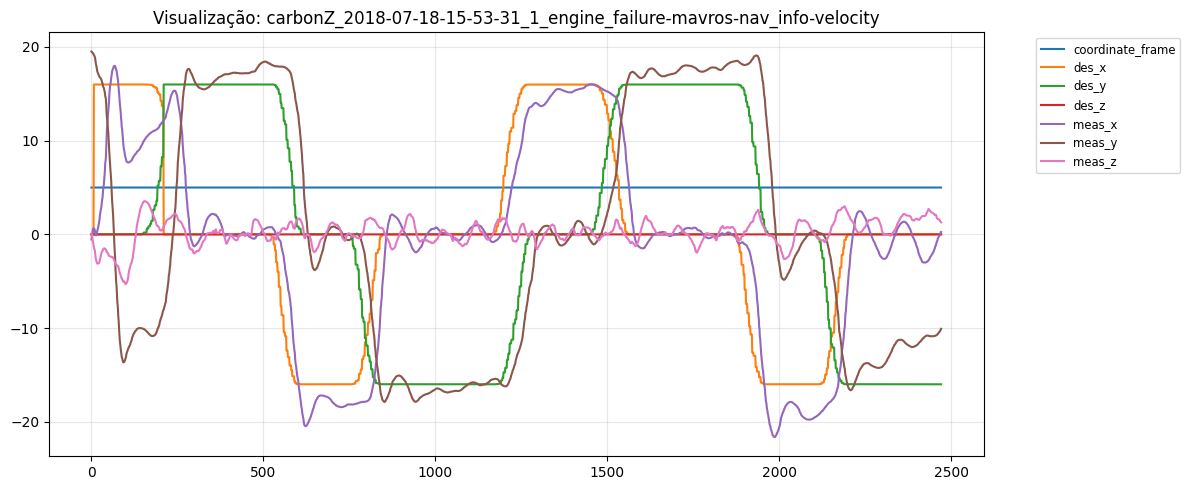

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-nav_info-velocity ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.coordinate_frame (Numérica)
6. field.des_x (Numérica)
7. field.des_y (Numérica)
8. field.des_z (Numérica)
9. field.meas_x (Numérica)
10. field.meas_y (Numérica)
11. field.meas_z (Numérica)




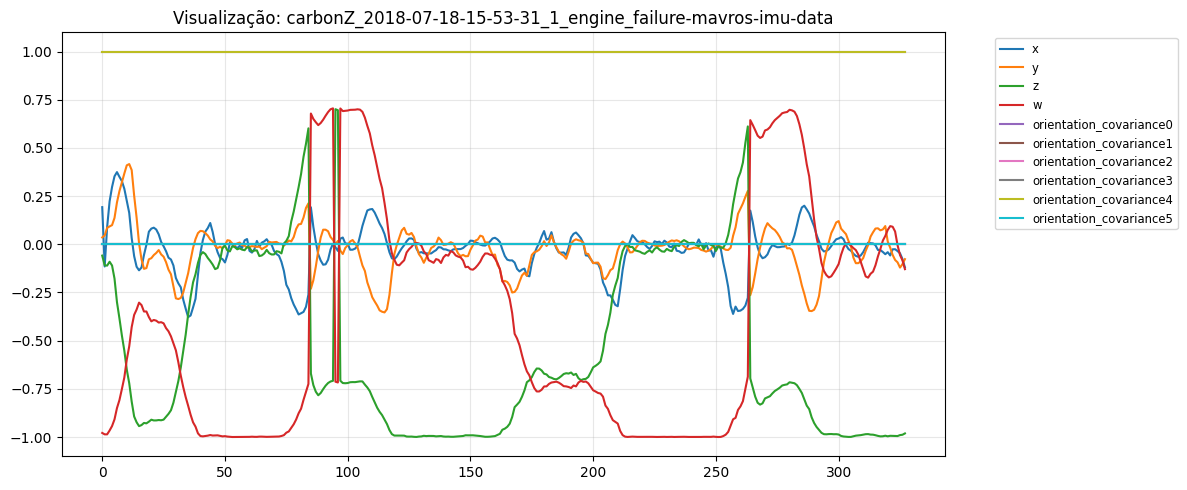

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-data ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.orientation.x (Numérica)
6. field.orientation.y (Numérica)
7. field.orientation.z (Numérica)
8. field.orientation.w (Numérica)
9. field.orientation_covariance0 (Numérica)
10. field.orientation_covariance1 (Numérica)
11. field.orientation_covariance2 (Numérica)
12. field.orientation_covariance3 (Numérica)
13. field.orientation_covariance4 (Numérica)
14. field.orientation_covariance5 (Numérica)
15. field.orientation_covariance6 (Numérica)
16. field.orientation_covariance7 (Numérica)
17. field.orientation_covariance8 (Numérica)
18. field.angular_velocity.x (Numérica)
19. field.angular_velocity.y (Numérica)
20. field.angular_velocity.z (Numérica)
21. field.angular_velocity_covariance0 (Numérica)
22. field.angular_velocity_covariance1 (Numérica)
23. field.angular_velocity_

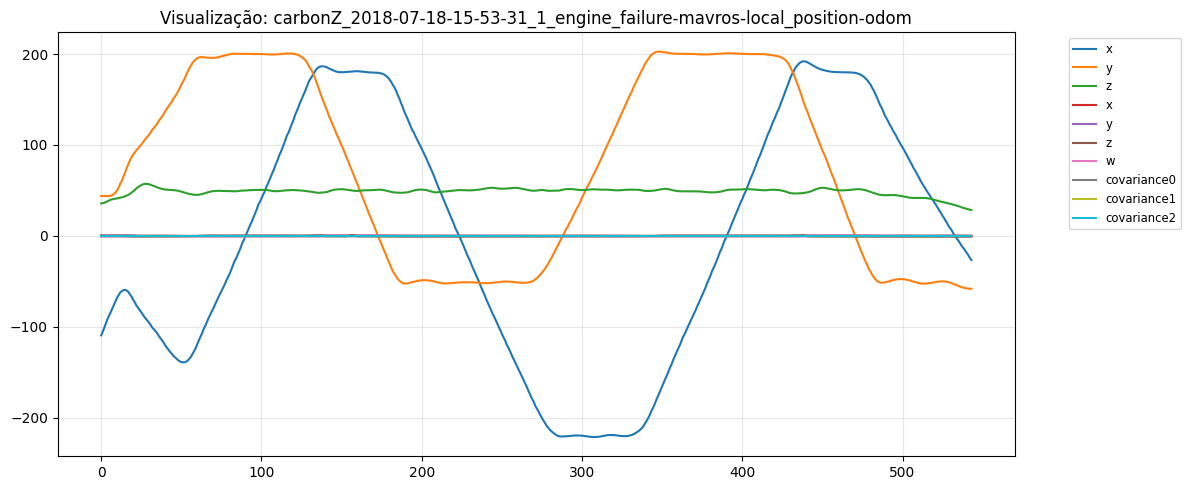

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-local_position-odom ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.child_frame_id (Não-Numérica)
6. field.pose.pose.position.x (Numérica)
7. field.pose.pose.position.y (Numérica)
8. field.pose.pose.position.z (Numérica)
9. field.pose.pose.orientation.x (Numérica)
10. field.pose.pose.orientation.y (Numérica)
11. field.pose.pose.orientation.z (Numérica)
12. field.pose.pose.orientation.w (Numérica)
13. field.pose.covariance0 (Numérica)
14. field.pose.covariance1 (Numérica)
15. field.pose.covariance2 (Numérica)
16. field.pose.covariance3 (Numérica)
17. field.pose.covariance4 (Numérica)
18. field.pose.covariance5 (Numérica)
19. field.pose.covariance6 (Numérica)
20. field.pose.covariance7 (Numérica)
21. field.pose.covariance8 (Numérica)
22. field.pose.covariance9 (Numérica)
23. field.pose.covariance10 (Numérica)
24. field.pose.c

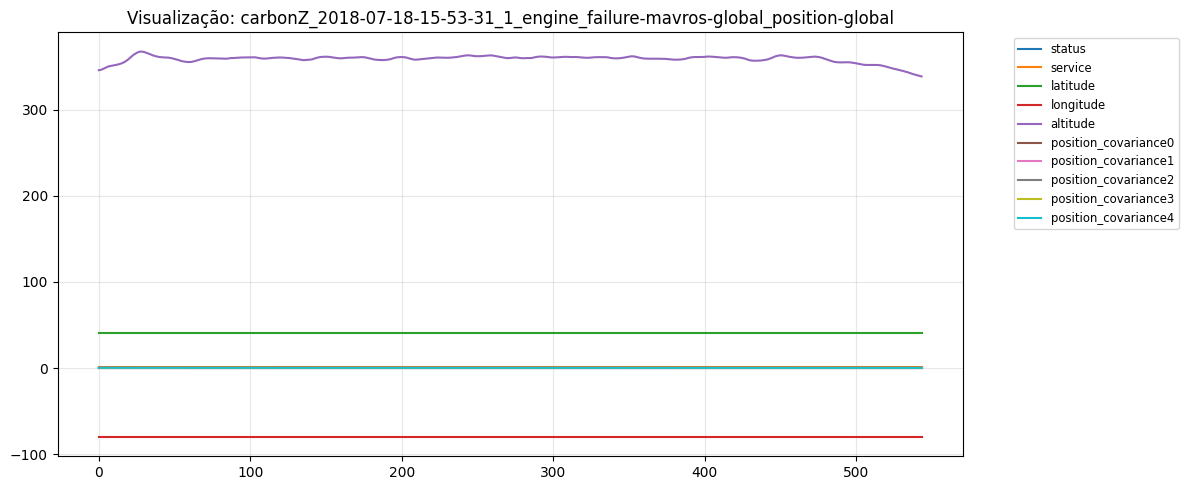

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-global ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.status.status (Numérica)
6. field.status.service (Numérica)
7. field.latitude (Numérica)
8. field.longitude (Numérica)
9. field.altitude (Numérica)
10. field.position_covariance0 (Numérica)
11. field.position_covariance1 (Numérica)
12. field.position_covariance2 (Numérica)
13. field.position_covariance3 (Numérica)
14. field.position_covariance4 (Numérica)
15. field.position_covariance5 (Numérica)
16. field.position_covariance6 (Numérica)
17. field.position_covariance7 (Numérica)
18. field.position_covariance8 (Numérica)
19. field.position_covariance_type (Numérica)




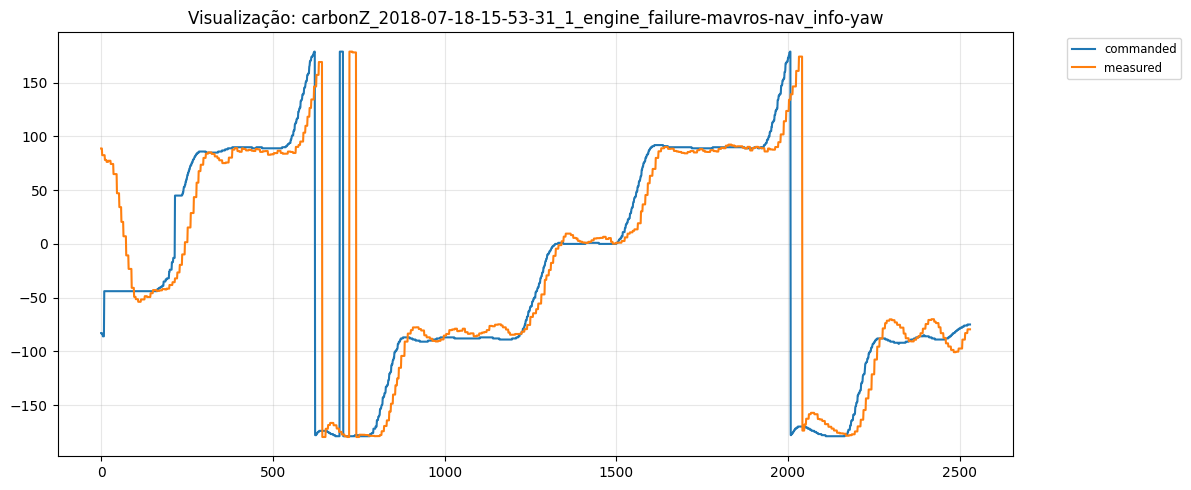

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-nav_info-yaw ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.commanded (Numérica)
6. field.measured (Numérica)




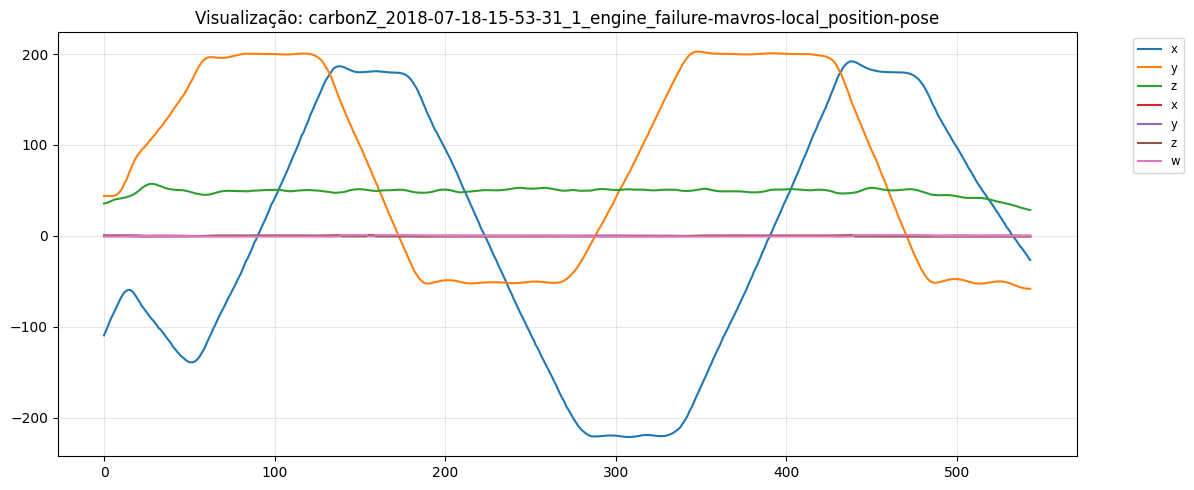

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-local_position-pose ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.pose.position.x (Numérica)
6. field.pose.position.y (Numérica)
7. field.pose.position.z (Numérica)
8. field.pose.orientation.x (Numérica)
9. field.pose.orientation.y (Numérica)
10. field.pose.orientation.z (Numérica)
11. field.pose.orientation.w (Numérica)




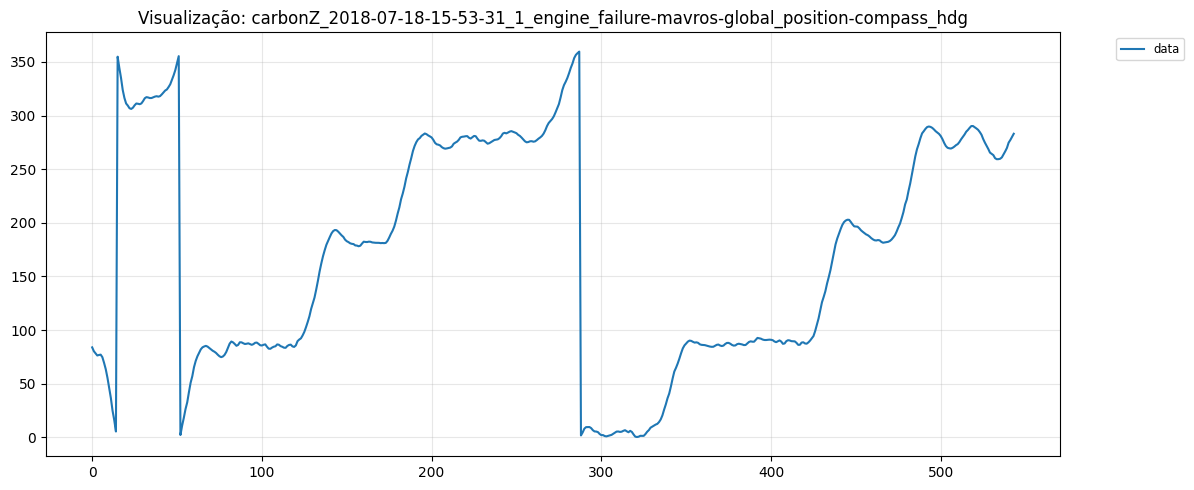

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-compass_hdg ---
1. %time (Numérica)
2. field.data (Numérica)




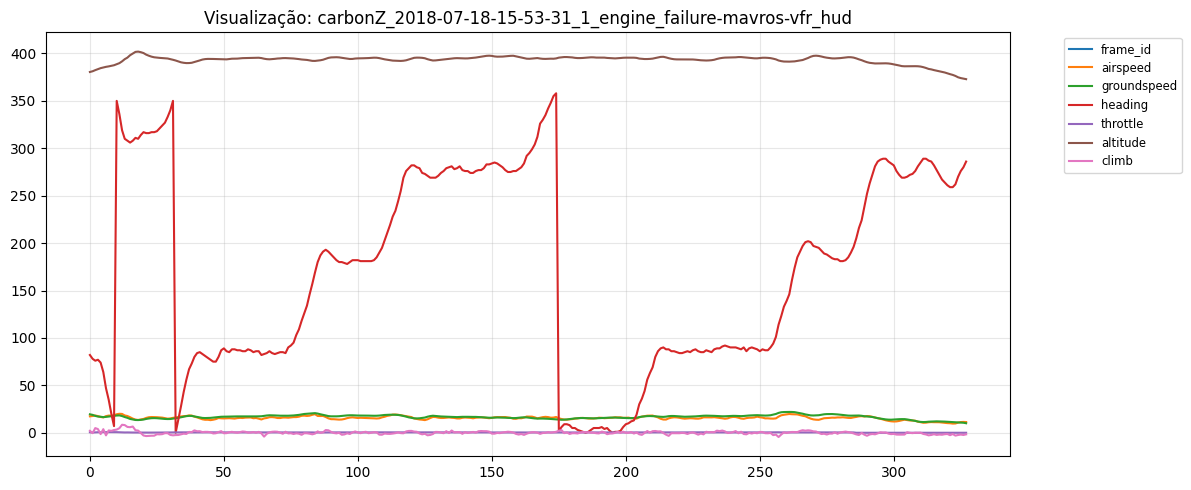

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-vfr_hud ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Numérica)
5. field.airspeed (Numérica)
6. field.groundspeed (Numérica)
7. field.heading (Numérica)
8. field.throttle (Numérica)
9. field.altitude (Numérica)
10. field.climb (Numérica)




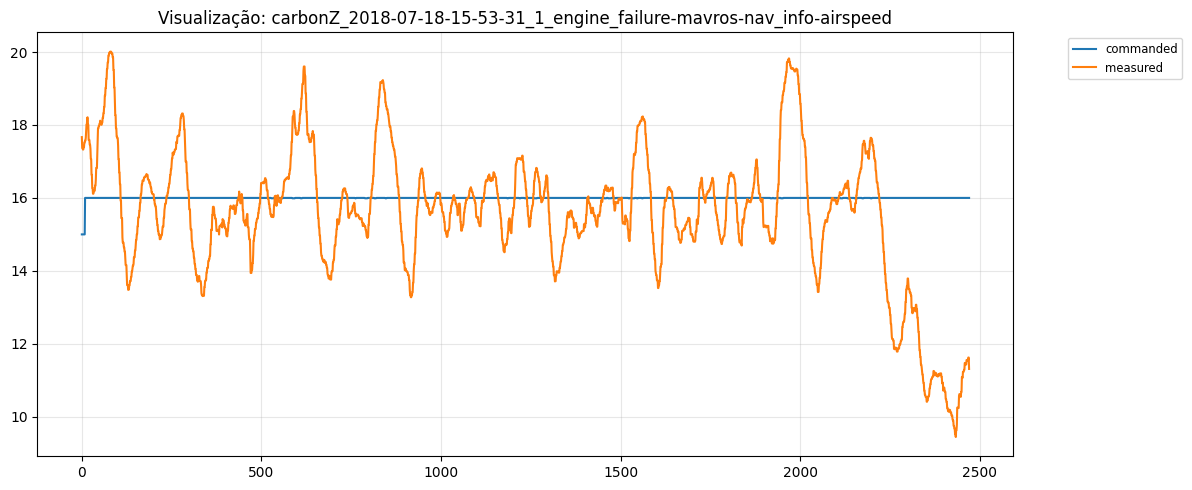

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-nav_info-airspeed ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.commanded (Numérica)
6. field.measured (Numérica)




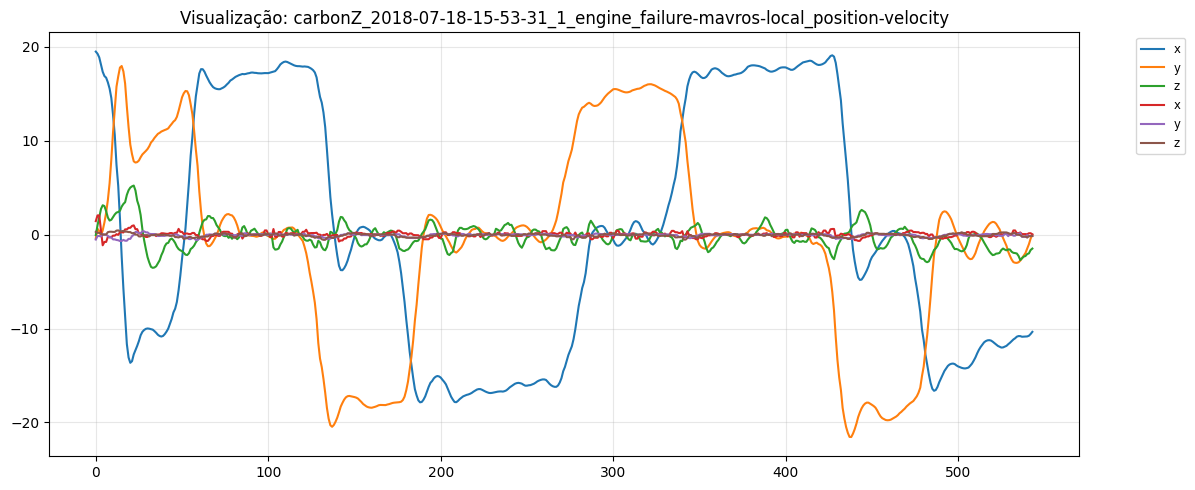

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-local_position-velocity ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.twist.linear.x (Numérica)
6. field.twist.linear.y (Numérica)
7. field.twist.linear.z (Numérica)
8. field.twist.angular.x (Numérica)
9. field.twist.angular.y (Numérica)
10. field.twist.angular.z (Numérica)




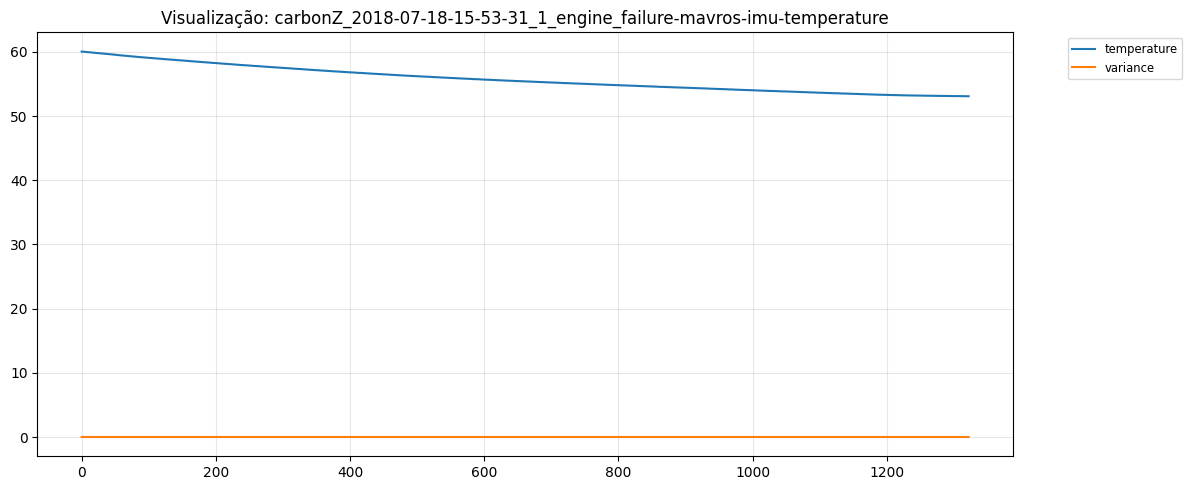

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-temperature ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.temperature (Numérica)
6. field.variance (Numérica)




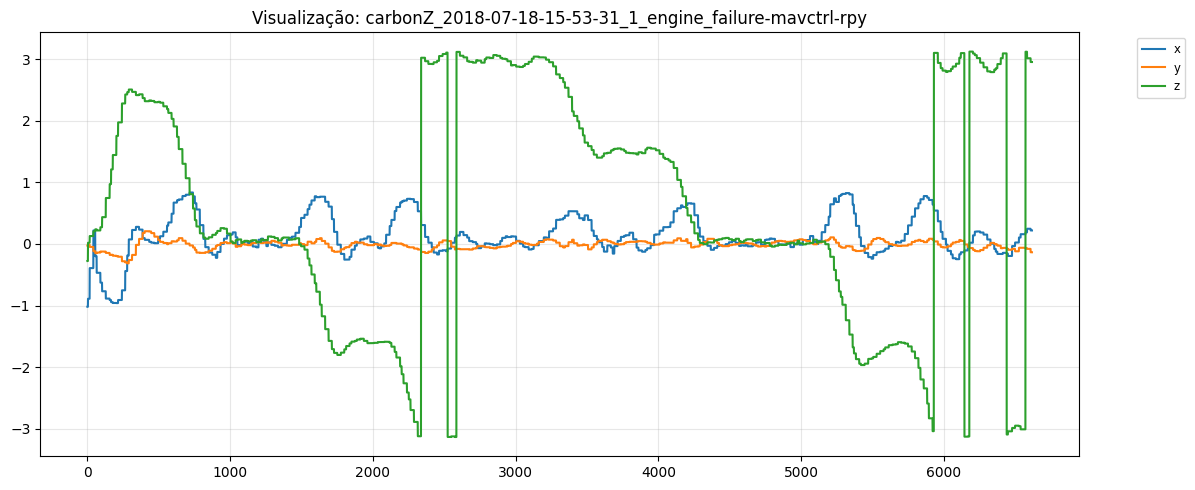

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavctrl-rpy ---
1. %time (Numérica)
2. field.x (Numérica)
3. field.y (Numérica)
4. field.z (Numérica)




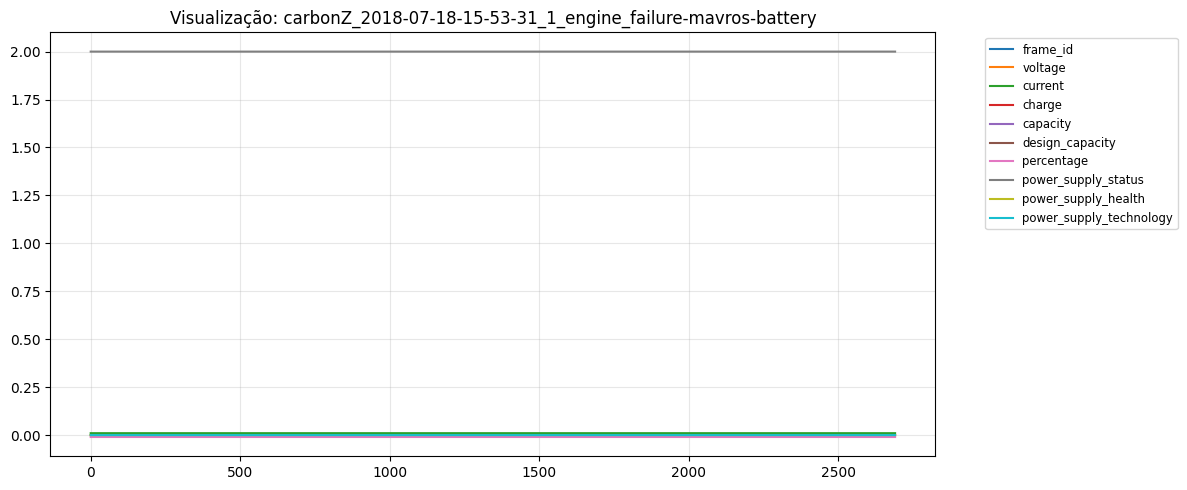

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-battery ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Numérica)
5. field.voltage (Numérica)
6. field.current (Numérica)
7. field.charge (Numérica)
8. field.capacity (Numérica)
9. field.design_capacity (Numérica)
10. field.percentage (Numérica)
11. field.power_supply_status (Numérica)
12. field.power_supply_health (Numérica)
13. field.power_supply_technology (Numérica)
14. field.present (Numérica)
15. field.location (Numérica)
16. field.serial_number (Numérica)




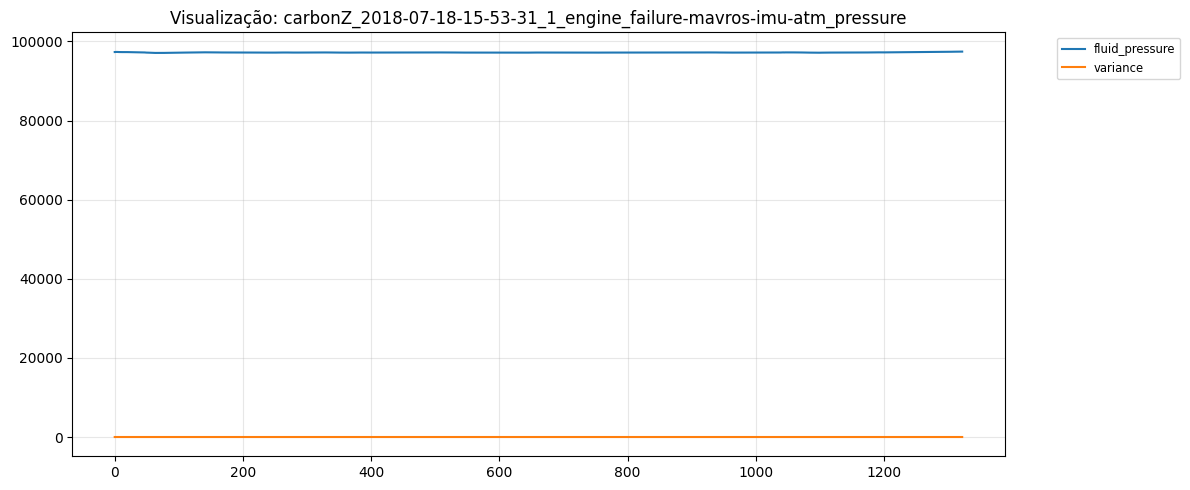

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-atm_pressure ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.fluid_pressure (Numérica)
6. field.variance (Numérica)




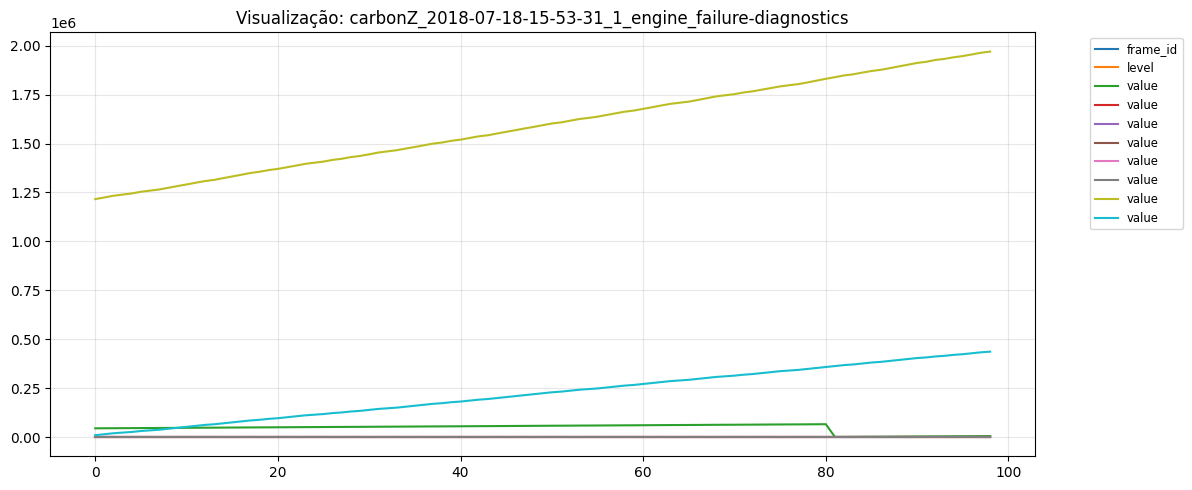

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Numérica)
5. field.status0.level (Numérica)
6. field.status0.name (Não-Numérica)
7. field.status0.message (Não-Numérica)
8. field.status0.hardware_id (Não-Numérica)
9. field.status0.values0.key (Não-Numérica)
10. field.status0.values0.value (Numérica)
11. field.status0.values1.key (Não-Numérica)
12. field.status0.values1.value (Numérica)
13. field.status0.values2.key (Não-Numérica)
14. field.status0.values2.value (Numérica)
15. field.status0.values3.key (Não-Numérica)
16. field.status0.values3.value (Numérica)
17. field.status0.values4.key (Não-Numérica)
18. field.status0.values4.value (Numérica)
19. field.status0.values5.key (Não-Numérica)
20. field.status0.values5.value (Numérica)
21. field.status0.values6.key (Não-Numérica)
22. field.status0.values6.value (Numérica)
23. field.status0.values7

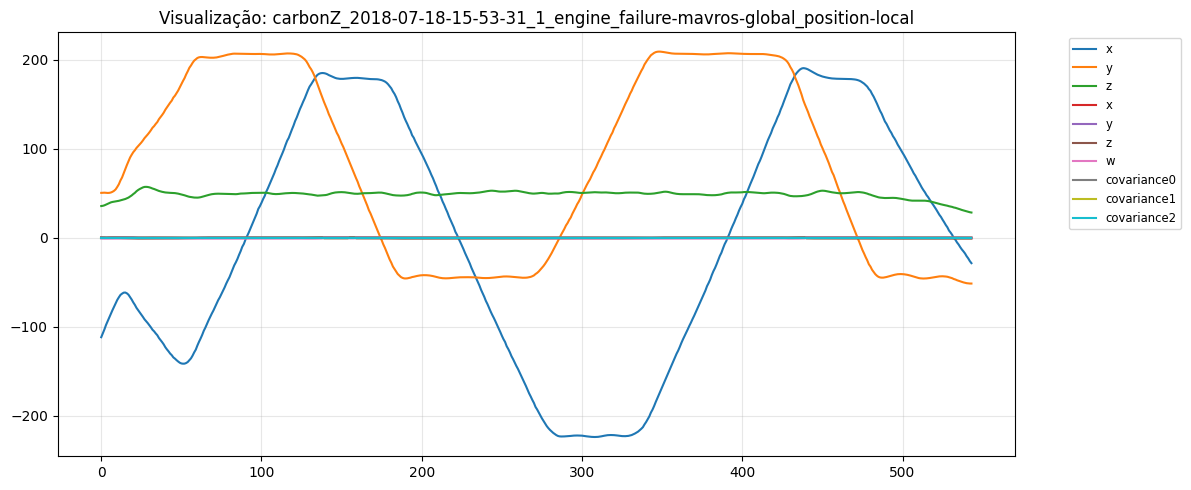

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-local ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.child_frame_id (Não-Numérica)
6. field.pose.pose.position.x (Numérica)
7. field.pose.pose.position.y (Numérica)
8. field.pose.pose.position.z (Numérica)
9. field.pose.pose.orientation.x (Numérica)
10. field.pose.pose.orientation.y (Numérica)
11. field.pose.pose.orientation.z (Numérica)
12. field.pose.pose.orientation.w (Numérica)
13. field.pose.covariance0 (Numérica)
14. field.pose.covariance1 (Numérica)
15. field.pose.covariance2 (Numérica)
16. field.pose.covariance3 (Numérica)
17. field.pose.covariance4 (Numérica)
18. field.pose.covariance5 (Numérica)
19. field.pose.covariance6 (Numérica)
20. field.pose.covariance7 (Numérica)
21. field.pose.covariance8 (Numérica)
22. field.pose.covariance9 (Numérica)
23. field.pose.covariance10 (Numérica)
24. field.pose

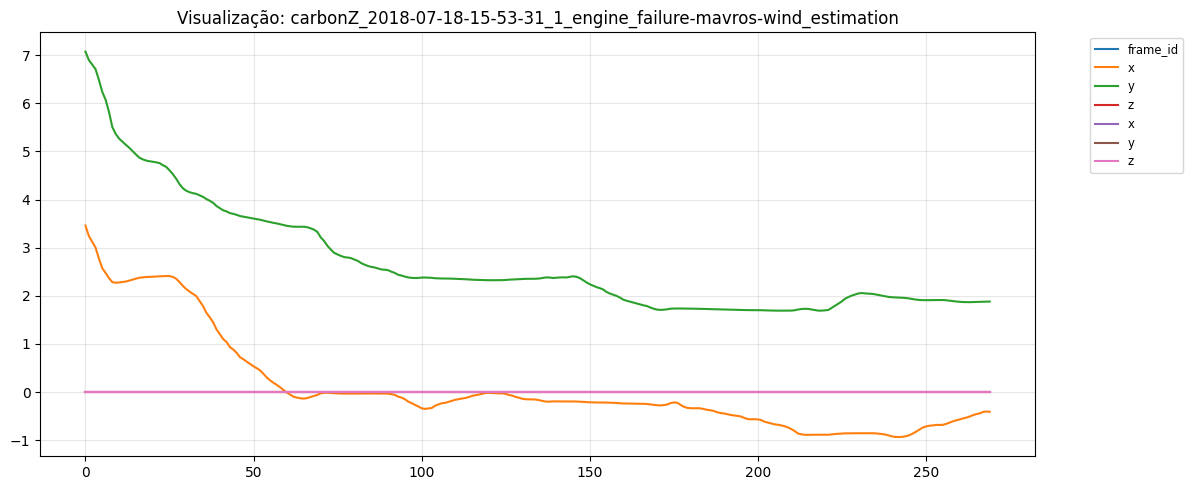

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-wind_estimation ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Numérica)
5. field.twist.linear.x (Numérica)
6. field.twist.linear.y (Numérica)
7. field.twist.linear.z (Numérica)
8. field.twist.angular.x (Numérica)
9. field.twist.angular.y (Numérica)
10. field.twist.angular.z (Numérica)




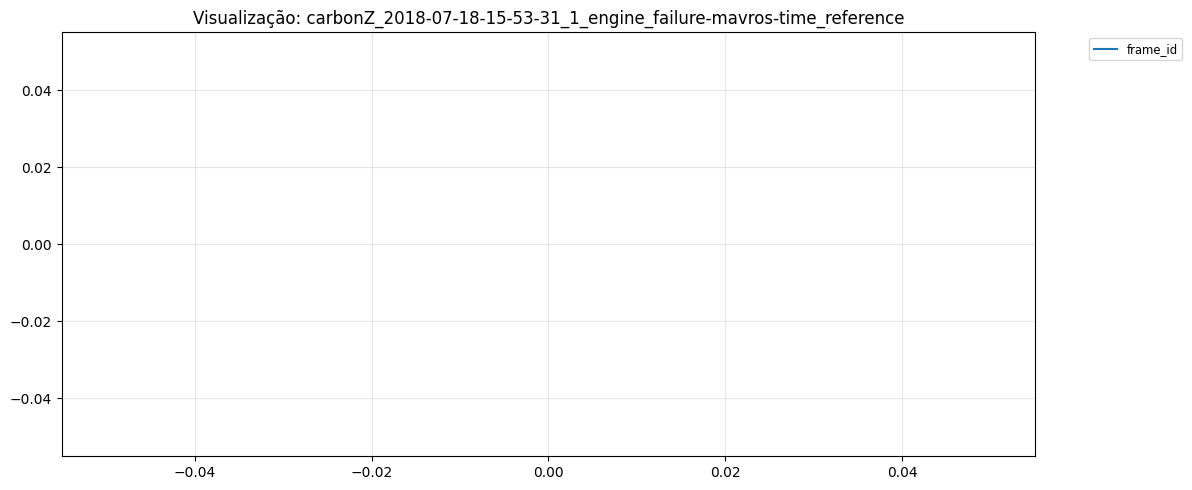

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-time_reference ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Numérica)
5. field.time_ref (Numérica)
6. field.source (Não-Numérica)




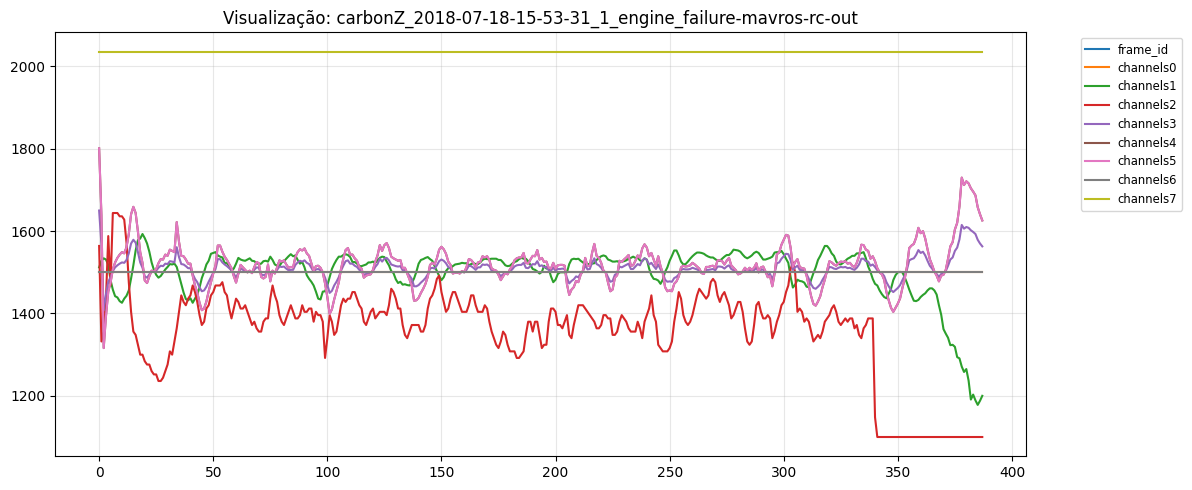

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-rc-out ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Numérica)
5. field.channels0 (Numérica)
6. field.channels1 (Numérica)
7. field.channels2 (Numérica)
8. field.channels3 (Numérica)
9. field.channels4 (Numérica)
10. field.channels5 (Numérica)
11. field.channels6 (Numérica)
12. field.channels7 (Numérica)




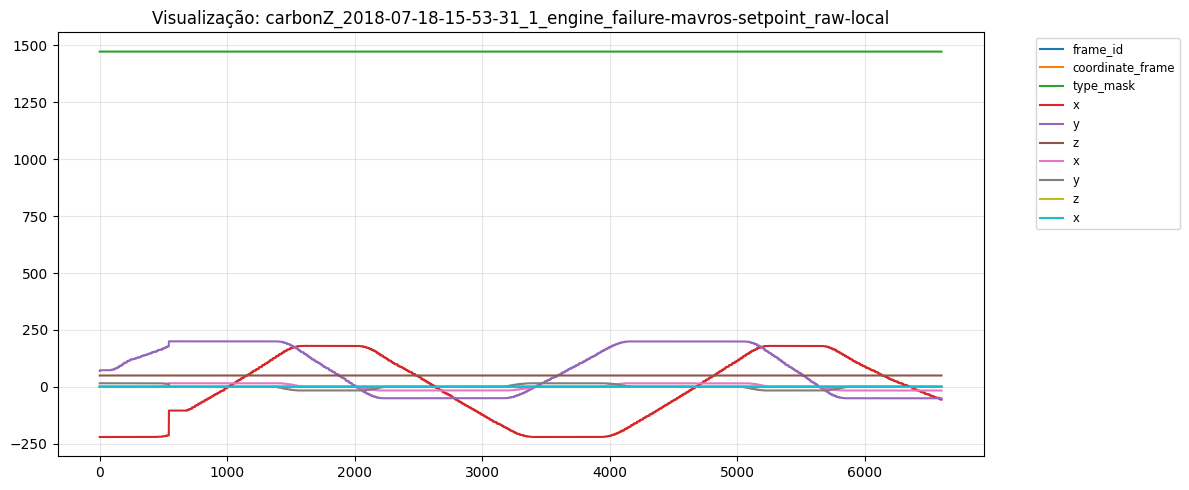

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-setpoint_raw-local ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Numérica)
5. field.coordinate_frame (Numérica)
6. field.type_mask (Numérica)
7. field.position.x (Numérica)
8. field.position.y (Numérica)
9. field.position.z (Numérica)
10. field.velocity.x (Numérica)
11. field.velocity.y (Numérica)
12. field.velocity.z (Numérica)
13. field.acceleration_or_force.x (Numérica)
14. field.acceleration_or_force.y (Numérica)
15. field.acceleration_or_force.z (Numérica)
16. field.yaw (Numérica)
17. field.yaw_rate (Numérica)




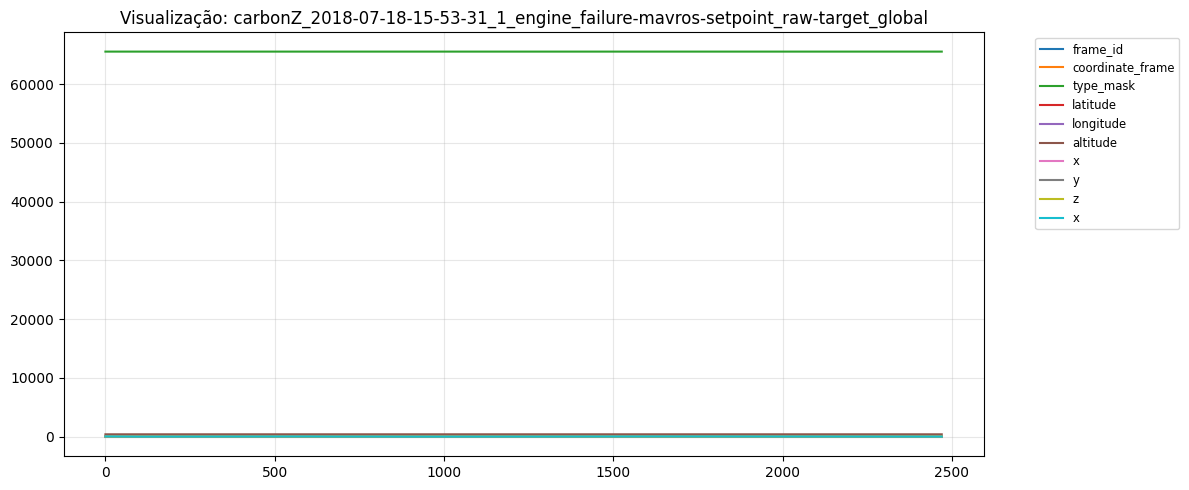

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-setpoint_raw-target_global ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Numérica)
5. field.coordinate_frame (Numérica)
6. field.type_mask (Numérica)
7. field.latitude (Numérica)
8. field.longitude (Numérica)
9. field.altitude (Numérica)
10. field.velocity.x (Numérica)
11. field.velocity.y (Numérica)
12. field.velocity.z (Numérica)
13. field.acceleration_or_force.x (Numérica)
14. field.acceleration_or_force.y (Numérica)
15. field.acceleration_or_force.z (Numérica)
16. field.yaw (Numérica)
17. field.yaw_rate (Numérica)




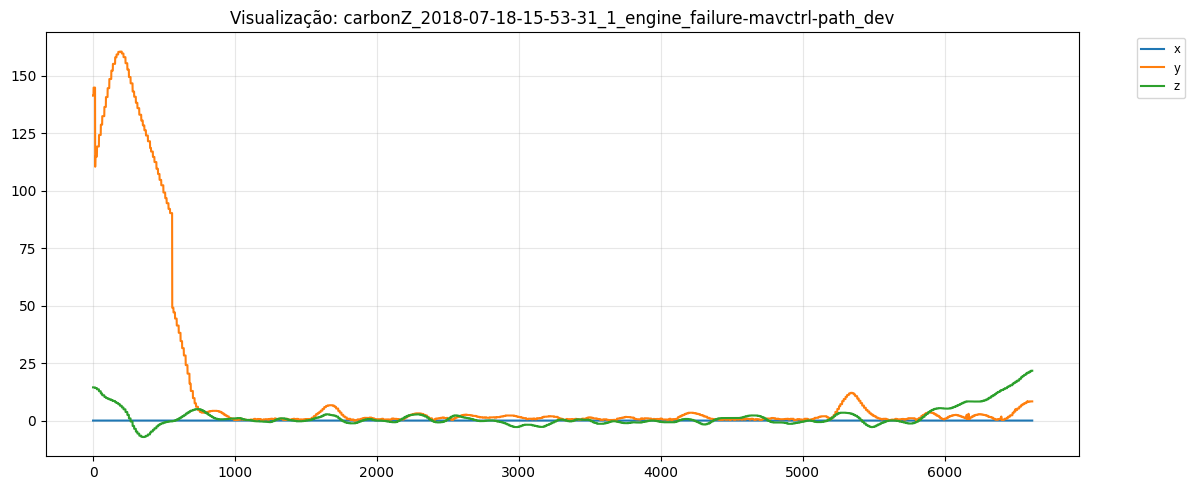

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavctrl-path_dev ---
1. %time (Numérica)
2. field.x (Numérica)
3. field.y (Numérica)
4. field.z (Numérica)




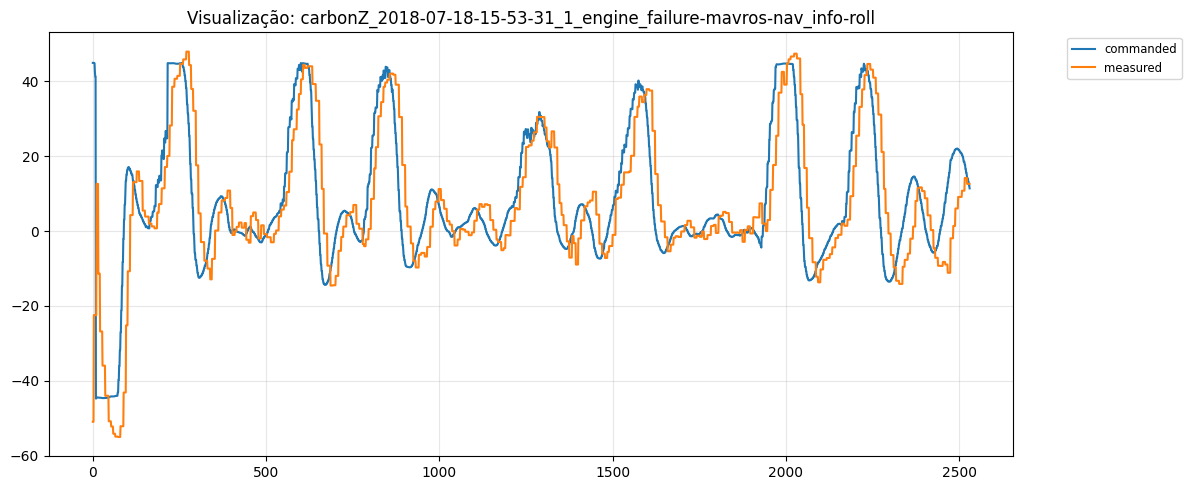

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-nav_info-roll ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.commanded (Numérica)
6. field.measured (Numérica)




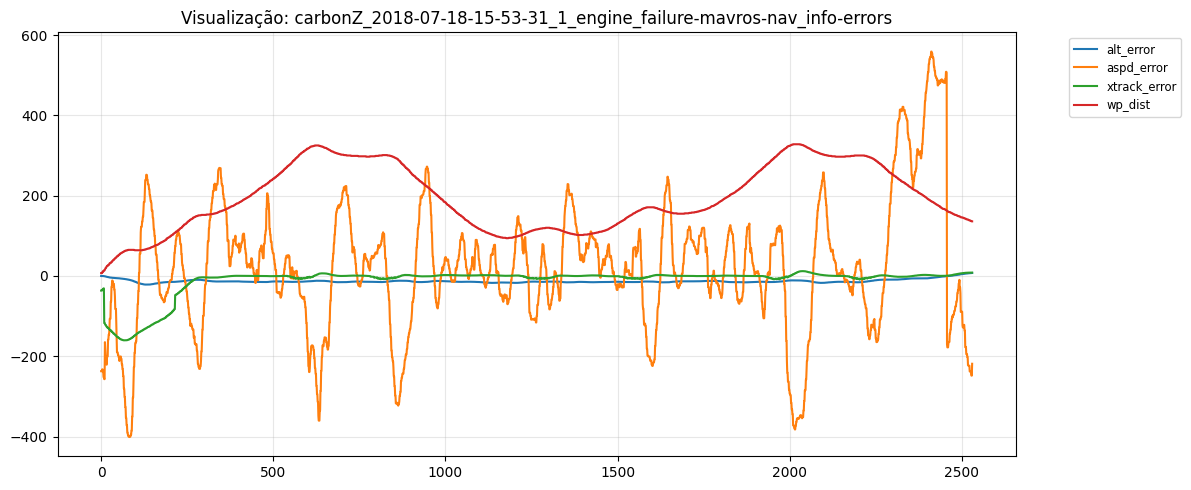

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-nav_info-errors ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.alt_error (Numérica)
6. field.aspd_error (Numérica)
7. field.xtrack_error (Numérica)
8. field.wp_dist (Numérica)




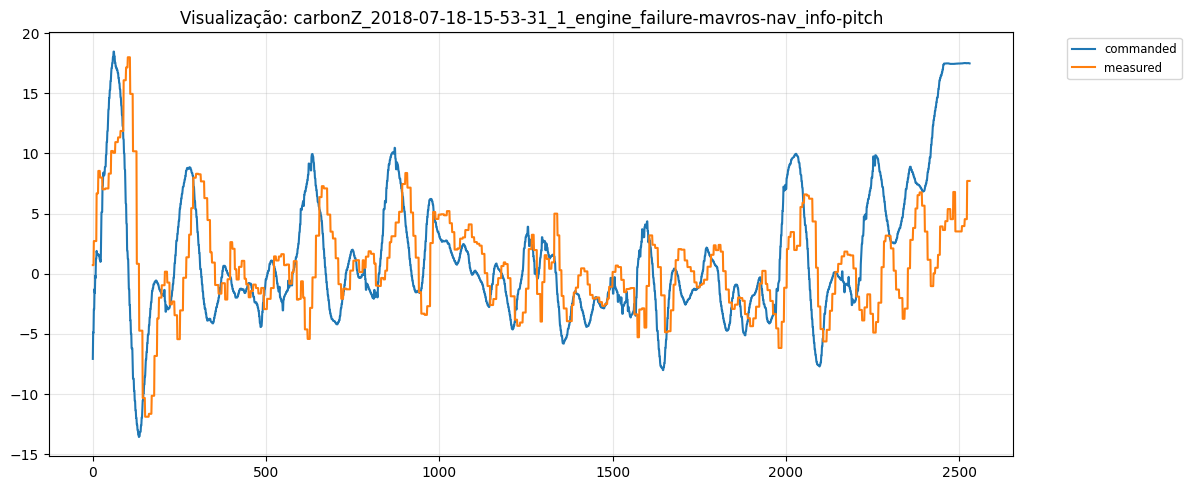

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-nav_info-pitch ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.commanded (Numérica)
6. field.measured (Numérica)




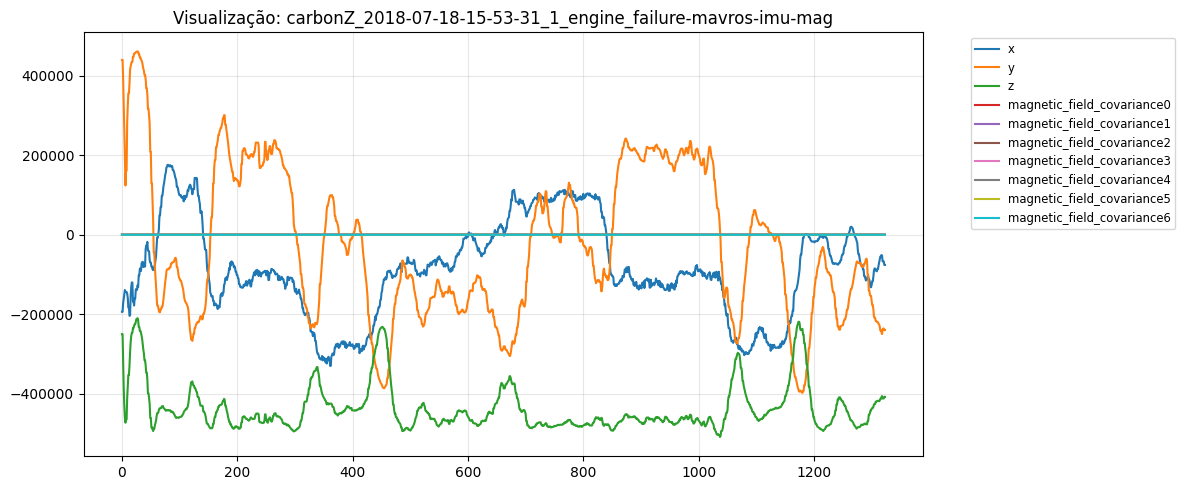

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-mag ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Não-Numérica)
5. field.magnetic_field.x (Numérica)
6. field.magnetic_field.y (Numérica)
7. field.magnetic_field.z (Numérica)
8. field.magnetic_field_covariance0 (Numérica)
9. field.magnetic_field_covariance1 (Numérica)
10. field.magnetic_field_covariance2 (Numérica)
11. field.magnetic_field_covariance3 (Numérica)
12. field.magnetic_field_covariance4 (Numérica)
13. field.magnetic_field_covariance5 (Numérica)
14. field.magnetic_field_covariance6 (Numérica)
15. field.magnetic_field_covariance7 (Numérica)
16. field.magnetic_field_covariance8 (Numérica)




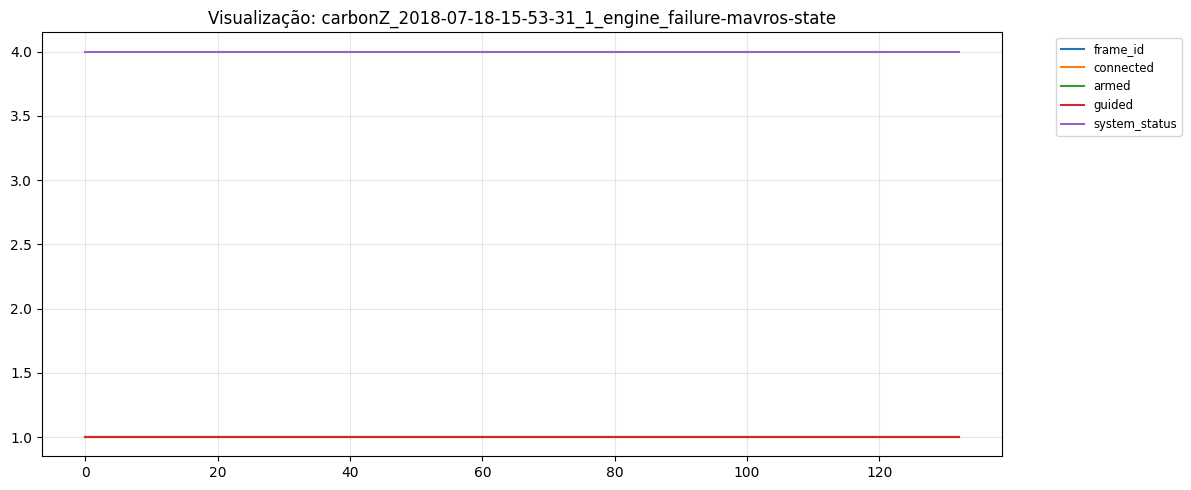

--- COLUNAS DO ARQUIVO: carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-state ---
1. %time (Numérica)
2. field.header.seq (Numérica)
3. field.header.stamp (Numérica)
4. field.header.frame_id (Numérica)
5. field.connected (Numérica)
6. field.armed (Numérica)
7. field.guided (Numérica)
8. field.mode (Não-Numérica)
9. field.system_status (Numérica)




In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Loop para explorar cada um dos 34 arquivos
for nome_arquivo, df in dfs.items():
    # 1. Separar colunas numéricas para plotagem
    cols_numericas = df.select_dtypes(include=['number']).columns.tolist()
    # Remover colunas de tempo da plotagem para não esmagar a escala dos outros dados
    cols_para_plot = [c for c in cols_numericas if 'time' not in c.lower() and 'stamp' not in c.lower() and 'seq' not in c.lower()]
    
    # 2. Criar a figura
    plt.figure(figsize=(12, 5))
    
    if cols_para_plot:
        # Plotar as colunas numéricas (limitando as 10 primeiras para não poluir)
        for col in cols_para_plot[:10]:
            plt.plot(df[col], label=col.split('.')[-1])
        
        plt.title(f"Visualização: {nome_arquivo}")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Sem dados numéricos para plotar', ha='center')
    
    plt.tight_layout()
    plt.show()

    # 3. Imprimir a lista completa de colunas (incluindo as não numéricas)
    print(f"--- COLUNAS DO ARQUIVO: {nome_arquivo} ---")
    for i, col in enumerate(df.columns):
        tipo = "Numérica" if col in cols_numericas else "Não-Numérica"
        print(f"{i+1}. {col} ({tipo})")
    print("\n" + "="*50 + "\n")

In [ ]:
caminho_datasets = ['../data/01_raw/processed/carbonZ_2018-07-18-15-53-31_1_engine_failure/carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-data.csv',
                    '../data/01_raw/processed/carbonZ_2018-07-18-15-53-31_1_engine_failure/carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-rc-out.csv']

In [2]:
# 1. Carregar os dados (Ajuste os nomes dos arquivos conforme sua pasta)
df_imu = pd.read_csv('../data/01_raw/processed/carbonZ_2018-07-18-15-53-31_1_engine_failure/carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-data.csv')
df_rc = pd.read_csv('../data/01_raw/processed/carbonZ_2018-07-18-15-53-31_1_engine_failure/carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-rc-out.csv')


In [3]:
target = pd.read_csv('../data/01_raw/processed/carbonZ_2018-07-18-15-53-31_1_engine_failure/carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-setpoint_raw-target_global.csv')

In [4]:
target

,%time,field.header.seq,field.header.stamp,field.header.frame_id,field.coordinate_frame,field.type_mask,field.latitude,field.longitude,field.altitude,field.velocity.x,field.velocity.y,field.velocity.z,field.acceleration_or_force.x,field.acceleration_or_force.y,field.acceleration_or_force.z,field.yaw,field.yaw_rate
0,1531943810865211553,2056,1531943810863209339,NaN,5,65528,40.591465,-79.89959,380.350006,0.0,0.000000,0.000000e+00,19.508381,-0.541918,-0.092209,-15.0,-17.666935
1,1531943810912319527,2057,1531943810910726171,NaN,5,65528,40.591465,-79.89959,380.350006,0.0,0.000000,0.000000e+00,19.482502,-0.264065,0.006710,-15.0,-17.372538
2,1531943810937148169,2058,1531943810936581328,NaN,5,65528,40.591465,-79.89959,380.350006,0.0,0.000000,0.000000e+00,19.453337,-0.001838,0.154981,-15.0,-17.372538
3,1531943810997412646,2059,1531943810996560529,NaN,5,65528,40.591465,-79.89959,380.350006,0.0,0.000000,0.000000e+00,19.410212,0.287959,0.444431,-15.0,-17.326405
4,1531943811057063853,2060,1531943811056638291,NaN,5,65528,40.591465,-79.89959,380.350006,0.0,0.000000,0.000000e+00,19.352375,0.503621,0.739515,-15.0,-17.326405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2466,1531943942982053456,4522,1531943942981303992,NaN,5,65528,40.591465,-79.89959,380.350006,-16.0,-0.000003,-1.959435e-15,-10.376916,-0.065727,-1.512439,-16.0,-11.538272
2467,1531943943036157851,4523,1531943943034999303,NaN,5,65528,40.591465,-79.89959,380.350006,-16.0,-0.000003,-1.959435e-15,-10.295895,0.052570,-1.416400,-16.0,-11.538272
2468,1531943943089063027,4524,1531943943088676471,NaN,5,65528,40.591465,-79.89959,380.350006,-16.0,-0.000003,-1.959435e-15,-10.233899,0.122478,-1.366917,-16.0,-11.624639
2469,1531943943115865691,4525,1531943943115640030,NaN,5,65528,40.591465,-79.89959,380.350006,-16.0,-0.000003,-1.959435e-15,-10.172915,0.180388,-1.325108,-16.0,-11.624639


In [5]:
df_imu.columns

Index(['%time', 'field.header.seq', 'field.header.stamp',
       'field.header.frame_id', 'field.orientation.x', 'field.orientation.y',
       'field.orientation.z', 'field.orientation.w',
       'field.orientation_covariance0', 'field.orientation_covariance1',
       'field.orientation_covariance2', 'field.orientation_covariance3',
       'field.orientation_covariance4', 'field.orientation_covariance5',
       'field.orientation_covariance6', 'field.orientation_covariance7',
       'field.orientation_covariance8', 'field.angular_velocity.x',
       'field.angular_velocity.y', 'field.angular_velocity.z',
       'field.angular_velocity_covariance0',
       'field.angular_velocity_covariance1',
       'field.angular_velocity_covariance2',
       'field.angular_velocity_covariance3',
       'field.angular_velocity_covariance4',
       'field.angular_velocity_covariance5',
       'field.angular_velocity_covariance6',
       'field.angular_velocity_covariance7',
       'field.angular_veloci

In [6]:
df_rc.columns

Index(['%time', 'field.header.seq', 'field.header.stamp',
       'field.header.frame_id', 'field.channels0', 'field.channels1',
       'field.channels2', 'field.channels3', 'field.channels4',
       'field.channels5', 'field.channels6', 'field.channels7'],
      dtype='str')

In [7]:
import pandas as pd
import numpy as np

# 1. Limpeza e Seleção de Colunas Relevantes
# No IMU: Tempo, Aceleração Linear (X é frente), Velocidade Angular (Vibração)
df_imu = df_imu[['%time', 'field.linear_acceleration.x', 
                 'field.angular_velocity.x', 'field.angular_velocity.y', 'field.angular_velocity.z',
                 'field.orientation.x', 'field.orientation.y', 'field.orientation.z', 'field.orientation.w']]

# No RC: Tempo e Channel 2 (Throttle/Motor)
df_rc = df_rc[['%time', 'field.channels2']]

# 2. Sincronização (Merge Asof)
df_imu = df_imu.sort_values('%time')
df_rc = df_rc.sort_values('%time')

df = pd.merge_asof(df_imu, df_rc, on='%time', direction='backward')

# 3. CRIAÇÃO DE FEATURES 

# A. Diferença de Aceleração (Delta Accel)
# Se o motor para, a aceleração em X cai bruscamente.
df['accel_delta'] = df['field.linear_acceleration.x'].diff()

# B. Intensidade de Vibração (Magnitude da Velocidade Angular)
# Motores geram ruído de alta frequência. Se o motor apaga, a vibração diminui.
df['vibration_intensity'] = np.sqrt(df['field.angular_velocity.x']**2 + 
                                    df['field.angular_velocity.y']**2 + 
                                    df['field.angular_velocity.z']**2)

# C. Eficiência do Motor (Relação Aceleração / Comando)
# Se o canal de comando (Throttle) está alto mas a aceleração é baixa, há algo errado.
# Adicionamos 1 ao denominador para evitar divisão por zero
df['engine_efficiency'] = df['field.linear_acceleration.x'] / (df['field.channels2'] + 1)

# 4. Criando o Lag (Passado recente)
# Para prever o comportamento, o modelo precisa saber o que aconteceu um instante antes
df['throttle_prev'] = df['field.channels2'].shift(5) # Lag de 5 amostras

df = df.dropna()


In [8]:
df.head(10)

,%time,field.linear_acceleration.x,field.angular_velocity.x,field.angular_velocity.y,field.angular_velocity.z,field.orientation.x,field.orientation.y,field.orientation.z,field.orientation.w,field.channels2,accel_delta,vibration_intensity,engine_efficiency,throttle_prev
5,1531943812812059050,1.814230,-0.283766,-0.288865,0.308480,0.352863,0.136949,-0.177657,-0.908389,1468,0.441299,0.509044,0.001235,1564.0
6,1531943813352840975,3.579427,-0.105808,-0.509014,0.288843,0.374671,0.217356,-0.299899,-0.849964,1644,1.765197,0.594744,0.002176,1332.0
7,1531943813677620625,3.402908,0.045404,-0.569728,0.428022,0.350326,0.275605,-0.383530,-0.808837,1644,-0.176520,0.714041,0.002069,1356.0
8,1531943814007042648,3.098901,-0.025609,-0.600880,0.449950,0.328265,0.322558,-0.472649,-0.751533,1636,-0.304006,0.751111,0.001893,1436.0
9,1531943814331942913,2.804702,0.256350,-0.679751,0.357788,0.288278,0.367327,-0.551564,-0.691190,1636,-0.294199,0.809808,0.001713,1588.0
10,1531943814739795375,2.726249,0.230176,-0.560436,0.397295,0.226109,0.409927,-0.650250,-0.598339,1628,-0.078453,0.724508,0.001674,1468.0
11,1531943815065878762,1.363124,0.559202,-0.650299,0.315949,0.162998,0.416341,-0.721100,-0.529251,1572,-1.363124,0.914013,0.000867,1644.0
12,1531943815523144465,0.441299,0.723987,-0.452044,0.270410,0.033006,0.385235,-0.816158,-0.429406,1404,-0.921825,0.895333,0.000314,1644.0
13,1531943815917907599,0.147100,0.927370,-0.160982,0.144797,-0.061218,0.252950,-0.893311,-0.366422,1356,-0.294199,0.952311,0.000108,1636.0
14,1531943816171819784,-0.117680,0.983467,-0.030496,0.179188,-0.116352,0.138773,-0.923313,-0.338671,1348,-0.264780,1.000122,-0.000087,1636.0


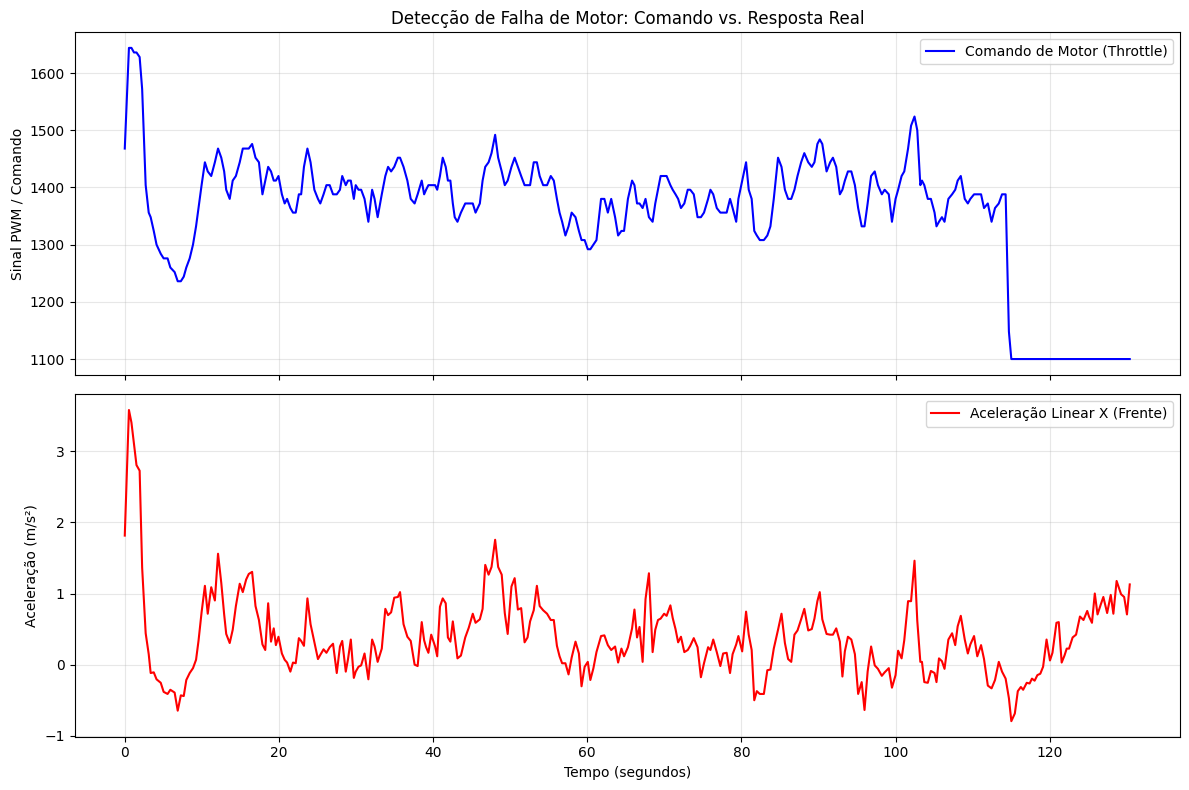

In [9]:
import matplotlib.pyplot as plt

def plot_engine_failure(df):
    # Criando a figura com dois subplots (um para o comando e outro para a resposta)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Normalizando o tempo para segundos (começando do zero)
    time_s = (df['%time'] - df['%time'].iloc[0]) / 1e9

    # Subplot 1: Comando de Motor (Throttle)
    ax1.plot(time_s, df['field.channels2'], color='blue', label='Comando de Motor (Throttle)')
    ax1.set_ylabel('Sinal PWM / Comando')
    ax1.set_title('Detecção de Falha de Motor: Comando vs. Resposta Real')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Subplot 2: Aceleração Frontal (Onde a falha aparece)
    ax2.plot(time_s, df['field.linear_acceleration.x'], color='red', label='Aceleração Linear X (Frente)')
    ax2.set_ylabel('Aceleração (m/s²)')
    ax2.set_xlabel('Tempo (segundos)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Rodar a visualização
plot_engine_failure(df)

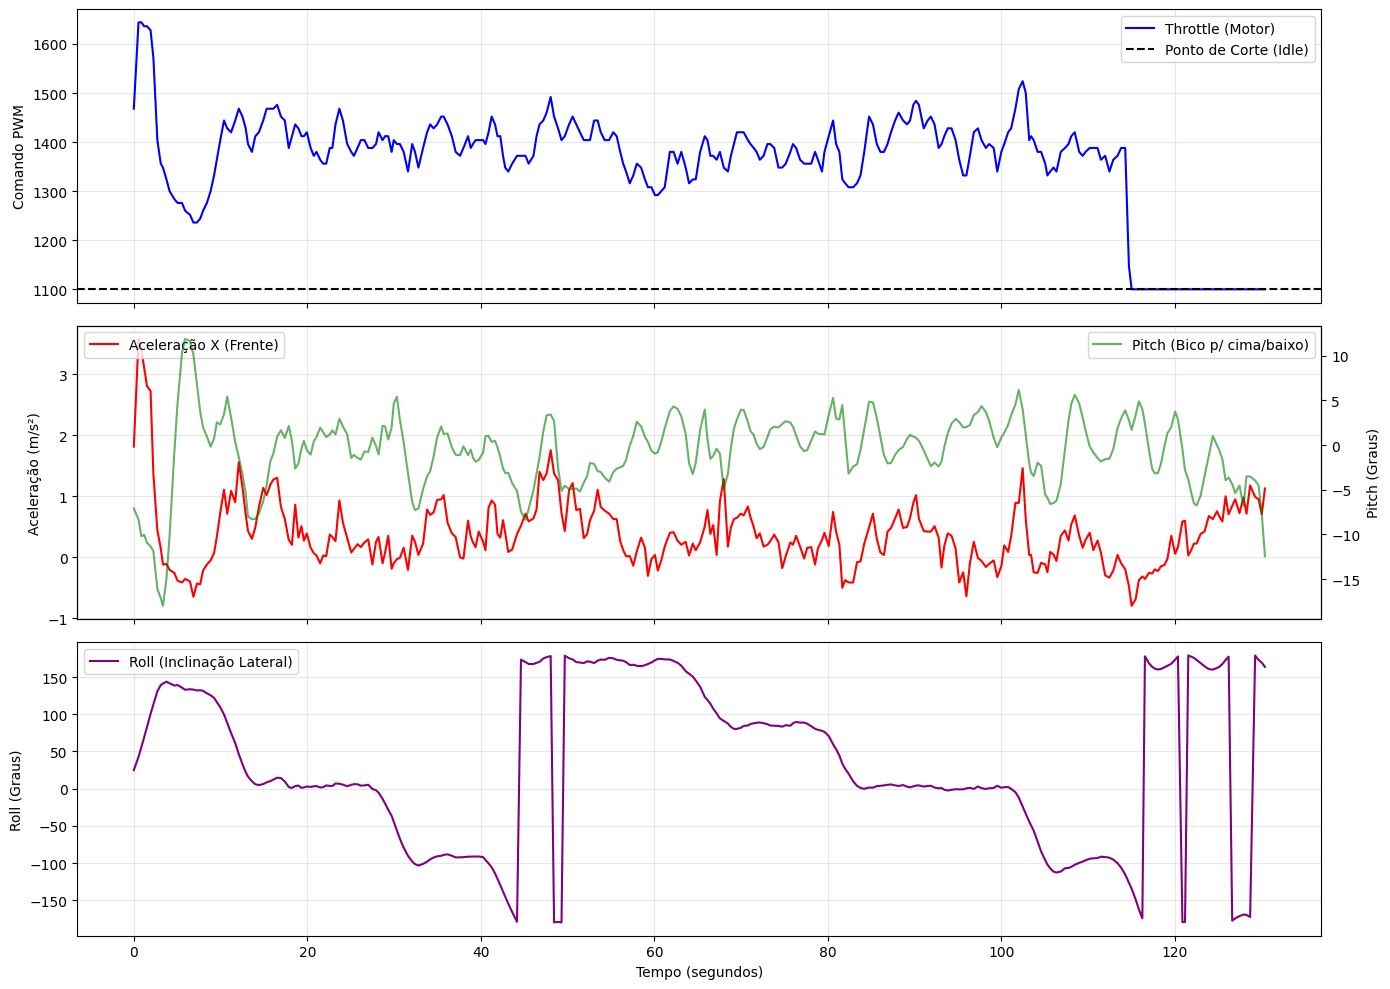

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

# 1. Carregar e Sincronizar 
# Vamos converter os quatérnios da IMU para Graus
def get_euler_angles(df):
    # Extrai os quatérnios
    quats = df[['field.orientation.x', 'field.orientation.y', 'field.orientation.z', 'field.orientation.w']].values
    # Converte para ângulos de Euler (em graus)
    rotation = R.from_quat(quats)
    euler = rotation.as_euler('xyz', degrees=True)
    df['pitch_deg'] = euler[:, 1]
    df['roll_deg'] = euler[:, 2]
    return df

df = get_euler_angles(df)

# 2. Visualização Profissional
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
time_s = (df['%time'] - df['%time'].iloc[0]) / 1e9

# Subplot 1: Comando de Motor
ax1.plot(time_s, df['field.channels2'], color='blue', label='Throttle (Motor)')
ax1.axhline(y=1100, color='black', linestyle='--', label='Ponto de Corte (Idle)')
ax1.set_ylabel('Comando PWM')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Subplot 2: Aceleração vs Pitch (A explicação física)
ax2.plot(time_s, df['field.linear_acceleration.x'], color='red', label='Aceleração X (Frente)')
ax2_twin = ax2.twinx() # Escala separada para o Pitch
ax2_twin.plot(time_s, df['pitch_deg'], color='green', label='Pitch (Bico p/ cima/baixo)', alpha=0.6)
ax2.set_ylabel('Aceleração (m/s²)')
ax2_twin.set_ylabel('Pitch (Graus)')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Subplot 3: Instabilidade Lateral (Roll)
ax3.plot(time_s, df['roll_deg'], color='purple', label='Roll (Inclinação Lateral)')
ax3.set_ylabel('Roll (Graus)')
ax3.set_xlabel('Tempo (segundos)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

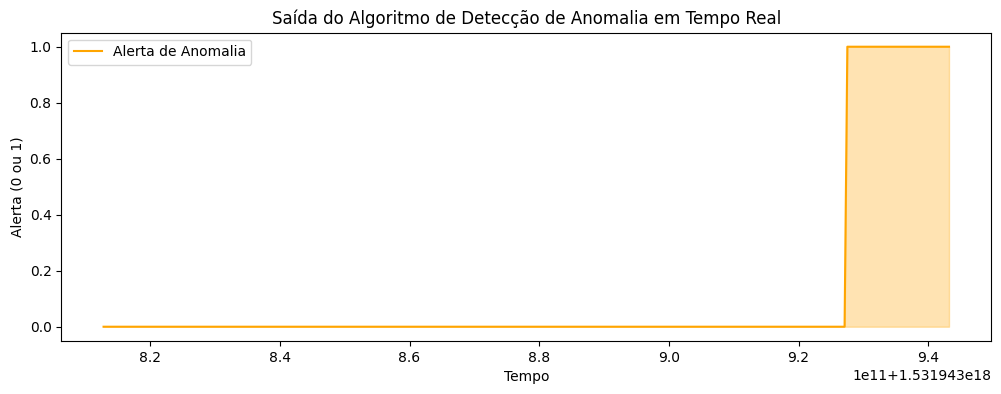

In [11]:
def detect_engine_failure_anomaly(df):
    # 1. Calculamos a variabilidade do Roll (instabilidade lateral)
    # Janela de 1 segundo (se a frequência for 50Hz, usar window=50)
    df['roll_std'] = df['roll_deg'].rolling(window=20).std()
    
    # 2. Definimos as condições da falha
    # Condição A: Motor cortado (PWM próximo de 1100)
    cond_motor = df['field.channels2'] <= 1150
    
    # Condição B: Instabilidade de Roll (desvio padrão alto)
    cond_roll = df['roll_std'] > 5 # Mais de 5 graus de oscilação
    
    # Condição C: Tendência de queda no Pitch
    cond_pitch = df['pitch_deg'] < -5
    
    # 3. Alerta Combinado
    df['anomaly_alert'] = np.where(cond_motor & (cond_roll | cond_pitch), 1, 0)
    
    return df

df = detect_engine_failure_anomaly(df)

# Plotando o resultado da detecção
plt.figure(figsize=(12,4))
plt.plot(df['%time'], df['anomaly_alert'], color='orange', label='Alerta de Anomalia')
plt.fill_between(df['%time'], 0, df['anomaly_alert'], color='orange', alpha=0.3)
plt.title("Saída do Algoritmo de Detecção de Anomalia em Tempo Real")
plt.xlabel("Tempo")
plt.ylabel("Alerta (0 ou 1)")
plt.legend()
plt.show()

In [12]:
# Encontrando o exato momento em que o comando de motor cai para o valor de falha
# Vamos considerar 1100 como o valor de corte
tempo_da_falha = df_rc[df_rc['field.channels2'] <= 1101]['%time'].min()

print(f"A falha foi injetada no timestamp: {tempo_da_falha}")

A falha foi injetada no timestamp: 1531943927688233537


In [21]:
cinco_segundos_em_ns = 5 * 1e9

t_corte_treino = tempo_da_falha - cinco_segundos_em_ns

# Dataset de Treino: Apenas o que é 100% garantido como saudável
df_treino = df[df['%time'] < t_corte_treino]

# Dataset de Teste: Começa um pouco antes da falha para vermos o modelo funcionando 
# no normal e depois disparando na anomalia
df_teste = df[df['%time'] >= t_corte_treino]

print(f"Linhas para treino: {len(df_treino)}")
print(f"Linhas para teste: {len(df_teste)}")

Linhas para treino: 252
Linhas para teste: 51


In [22]:
# Criando o Ground Truth: 0 para normal, 1 para falha
df['ground_truth'] = (df['%time'] >= tempo_da_falha).astype(int)

In [23]:
df

,%time,field.linear_acceleration.x,field.angular_velocity.x,field.angular_velocity.y,field.angular_velocity.z,field.orientation.x,field.orientation.y,field.orientation.z,field.orientation.w,field.channels2,accel_delta,vibration_intensity,engine_efficiency,throttle_prev,pitch_deg,roll_deg,roll_std,anomaly_alert,ground_truth,roll_rate_prev
25,1531943820793614620,-0.215746,0.082621,-0.060920,-0.063676,-0.010031,-0.064403,-0.909755,-0.409998,1260,0.225553,0.120797,-0.000171,1260.0,1.980434,131.605544,31.053388,0,0,0.114319
26,1531943821233863517,-0.117680,0.165507,-0.085392,-0.124968,-0.035961,-0.093063,-0.894863,-0.435047,1276,0.098067,0.224280,-0.000092,1252.0,0.951946,128.240709,25.453595,0,0,0.082621
27,1531943821663172780,-0.049033,0.091908,-0.027924,-0.068666,-0.069333,-0.131678,-0.879777,-0.451493,1300,0.068647,0.118076,-0.000038,1236.0,-0.177192,125.640477,19.958793,0,0,0.165507
28,1531943822059054206,0.068647,0.190954,0.008891,-0.263003,-0.078861,-0.155485,-0.861065,-0.477674,1332,0.117680,0.325135,0.000051,1236.0,0.729626,122.090650,14.891387,0,0,0.091908
29,1531943822376901254,0.333426,0.611613,-0.079148,-0.308182,-0.109862,-0.218550,-0.821868,-0.514488,1364,0.264780,0.689428,0.000244,1244.0,2.538942,116.545136,10.724430,0,0,0.190954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,1531943941491996642,1.176798,0.053843,-0.234794,-0.195660,-0.025433,-0.081257,-0.994152,0.066418,1100,0.460913,0.310339,0.001069,1100.0,-3.517971,-172.636302,167.950262,1,1,0.229043
324,1531943942067681887,0.990472,0.036893,-0.056033,-0.316570,-0.035190,-0.093619,-0.994974,-0.004850,1100,-0.186326,0.323601,0.000900,1100.0,-3.963370,179.067238,161.240647,1,1,0.053843
325,1531943942472051935,0.951245,0.146542,-0.159355,-0.158169,-0.046766,-0.120761,-0.990011,-0.055751,1100,-0.039227,0.268116,0.000864,1100.0,-4.538691,172.988629,161.020145,1,1,0.036893
326,1531943942834921809,0.706079,0.036797,-0.132573,-0.143827,-0.076616,-0.102990,-0.988213,-0.083416,1100,-0.245166,0.199037,0.000641,1100.0,-7.714883,169.496449,160.746084,1,1,0.146542


In [26]:
features = ['field.channels2', 'pitch_deg', 'roll_deg', 'roll_rate_prev']
target = 'field.linear_acceleration.x'

# Treino
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(df_treino[features], df_treino[target])

# --- DETECÇÃO E 3 SIGMAS ---

# Erro no treino para definir o limiar (baseline de erro "normal")
preds_treino = model.predict(df_treino[features])
erros_treino = np.abs(df_treino[target] - preds_treino)
limiar = erros_treino.mean() + (3 * erros_treino.std())

# Predição no teste
preds_teste = model.predict(df_teste[features])
erro_teste = np.abs(df_teste[target] - preds_teste)

# O Gatilho de Anomalia
df_teste['pred_anomalia'] = (erro_teste > limiar).astype(int)

# --- VALIDAÇÃO FINAL ---
print("Relatório de Performance do Detector:")
print(classification_report(df_teste['ground_truth'], df_teste['pred_anomalia']))

Relatório de Performance do Detector:
              precision    recall  f1-score   support

           0       0.33      0.64      0.44        11
           1       0.87      0.65      0.74        40

    accuracy                           0.65        51
   macro avg       0.60      0.64      0.59        51
weighted avg       0.75      0.65      0.68        51

